In [1]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password="Shanks@123",
    host="localhost",
    port=5432,
    database="job_market_db"
)

engine = create_engine(connection_url)

print("Connected to PostgreSQL")

Connected to PostgreSQL


In [2]:
query = """
SELECT
    s.skill_name,
    COUNT(DISTINCT js.job_id) AS job_count
FROM job_skills js
JOIN skills s
    ON js.skill_id = s.skill_id
GROUP BY s.skill_name
ORDER BY job_count DESC;
"""

skill_demand = pd.read_sql(query, engine)

skill_demand.head(30)

,skill_name,job_count
0,SAP,5606
1,SQL,4164
2,Agile,3641
3,Python,3517
4,Java,3479
5,Azure,3422
6,Excel,3343
7,AWS,3297
8,Research,2335
9,Software Development,2242


In [3]:
total_jobs = 97679

skill_demand["demand_percent"] = (
    skill_demand["job_count"] / total_jobs * 100
).round(2)

skill_demand.head(30)

,skill_name,job_count,demand_percent
0,SAP,5606,5.74
1,SQL,4164,4.26
2,Agile,3641,3.73
3,Python,3517,3.60
4,Java,3479,3.56
5,Azure,3422,3.50
6,Excel,3343,3.42
7,AWS,3297,3.38
8,Research,2335,2.39
9,Software Development,2242,2.30


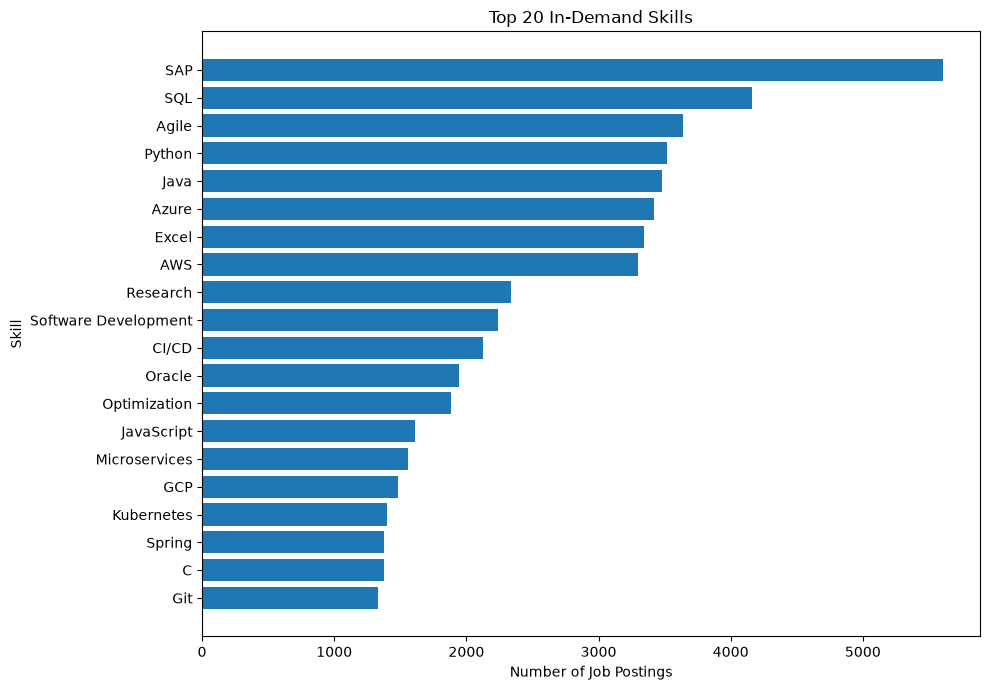

In [7]:
import matplotlib.pyplot as plt

top20 = skill_demand.head(20).sort_values(
    "job_count"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top20["skill_name"],
    top20["job_count"]
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.title("Top 20 In-Demand Skills")

plt.tight_layout()
plt.show()

In [8]:
total_jobs = 97679

skill_demand["demand_percent"] = (
    skill_demand["job_count"] / total_jobs * 100
).round(2)

skill_demand.head(20)

,skill_name,job_count,demand_percent
0,SAP,5606,5.74
1,SQL,4164,4.26
2,Agile,3641,3.73
3,Python,3517,3.60
4,Java,3479,3.56
5,Azure,3422,3.50
6,Excel,3343,3.42
7,AWS,3297,3.38
8,Research,2335,2.39
9,Software Development,2242,2.30


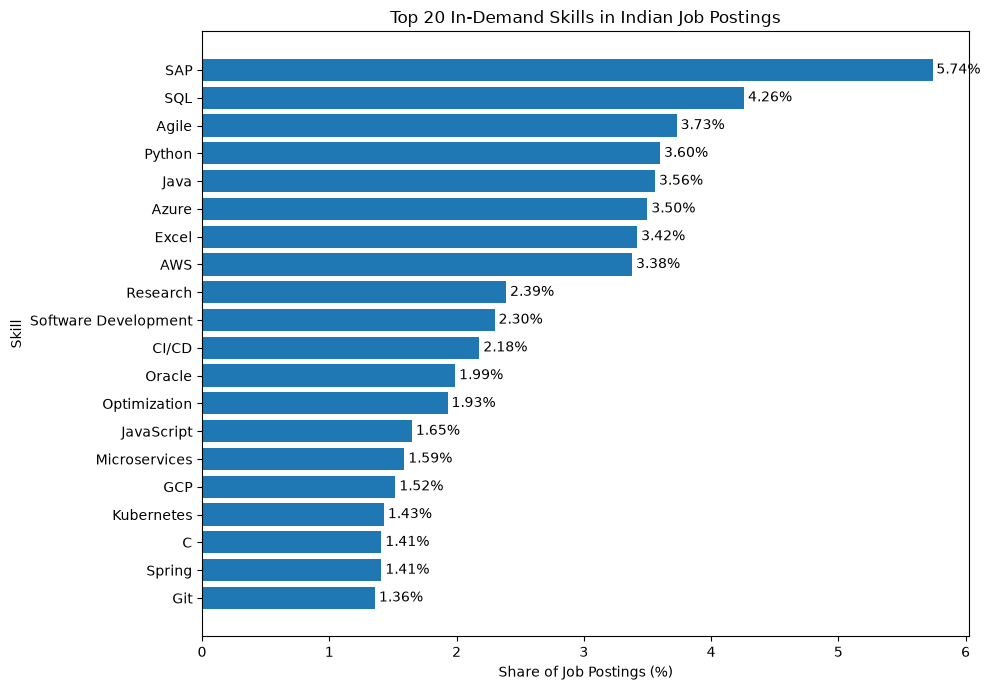

In [9]:
import matplotlib.pyplot as plt

top20 = skill_demand.head(20).sort_values("demand_percent")

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top20["skill_name"],
    top20["demand_percent"]
)

plt.xlabel("Share of Job Postings (%)")
plt.ylabel("Skill")
plt.title("Top 20 In-Demand Skills in Indian Job Postings")

for bar, value in zip(bars, top20["demand_percent"]):
    plt.text(
        value + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [11]:
from sqlalchemy import text

roles = pd.read_sql(
    text(role_query),
    engine
)

roles["role"].value_counts()

role
Software Engineer       1563
Full Stack Developer    1512
QA / Testing            1145
Data Engineer           1082
DevOps Engineer          664
Java Developer           652
Project Manager          558
Business Analyst         499
Backend Developer        447
Software Developer       319
Data Scientist           317
Data Analyst             267
Python Developer         243
Frontend Developer       226
Cloud Engineer            94
Name: count, dtype: int64

In [12]:
role_counts = (
    roles["role"]
    .dropna()
    .value_counts()
    .reset_index()
)

role_counts.columns = ["role", "job_count"]

role_counts

,role,job_count
0,Software Engineer,1563
1,Full Stack Developer,1512
2,QA / Testing,1145
3,Data Engineer,1082
4,DevOps Engineer,664
5,Java Developer,652
6,Project Manager,558
7,Business Analyst,499
8,Backend Developer,447
9,Software Developer,319


In [13]:
role_skill_query = """
SELECT
    r.role,
    s.skill_name,
    COUNT(DISTINCT js.job_id) AS job_count
FROM (
    SELECT
        job_id,
        CASE
            WHEN LOWER(title) LIKE '%data scientist%' THEN 'Data Scientist'
            WHEN LOWER(title) LIKE '%data analyst%' THEN 'Data Analyst'
            WHEN LOWER(title) LIKE '%data engineer%' THEN 'Data Engineer'
            WHEN LOWER(title) LIKE '%python developer%' THEN 'Python Developer'
            WHEN LOWER(title) LIKE '%java developer%' THEN 'Java Developer'
            WHEN LOWER(title) LIKE '%software engineer%' THEN 'Software Engineer'
            WHEN LOWER(title) LIKE '%software developer%' THEN 'Software Developer'
            WHEN LOWER(title) LIKE '%devops%' THEN 'DevOps Engineer'
            WHEN LOWER(title) LIKE '%cloud engineer%' THEN 'Cloud Engineer'
            WHEN LOWER(title) LIKE '%frontend%'
              OR LOWER(title) LIKE '%front end%' THEN 'Frontend Developer'
            WHEN LOWER(title) LIKE '%backend%'
              OR LOWER(title) LIKE '%back end%' THEN 'Backend Developer'
            WHEN LOWER(title) LIKE '%full stack%'
              OR LOWER(title) LIKE '%fullstack%' THEN 'Full Stack Developer'
            WHEN LOWER(title) LIKE '%qa%'
              OR LOWER(title) LIKE '%quality analyst%'
              OR LOWER(title) LIKE '%test engineer%' THEN 'QA / Testing'
            WHEN LOWER(title) LIKE '%business analyst%' THEN 'Business Analyst'
            WHEN LOWER(title) LIKE '%project manager%' THEN 'Project Manager'
            ELSE NULL
        END AS role
    FROM jobs
) r
JOIN job_skills js
    ON r.job_id = js.job_id
JOIN skills s
    ON js.skill_id = s.skill_id
WHERE r.role IS NOT NULL
GROUP BY r.role, s.skill_name
ORDER BY r.role, job_count DESC;
"""

role_skills = pd.read_sql(
    text(role_skill_query),
    engine
)

print(role_skills.shape)
role_skills.head(30)

(2671, 3)


,role,skill_name,job_count
0,Backend Developer,Java,163
1,Backend Developer,Spring,120
2,Backend Developer,Microservices,98
3,Backend Developer,Spring Boot,89
4,Backend Developer,AWS,83
5,Backend Developer,Python,72
6,Backend Developer,SQL,70
7,Backend Developer,CI/CD,57
8,Backend Developer,Azure,56
9,Backend Developer,Kubernetes,49


In [14]:
top_role_skills = (
    role_skills
    .sort_values(
        ["role", "job_count"],
        ascending=[True, False]
    )
    .groupby("role")
    .head(10)
)

top_role_skills

,role,skill_name,job_count
0,Backend Developer,Java,163
1,Backend Developer,Spring,120
2,Backend Developer,Microservices,98
3,Backend Developer,Spring Boot,89
4,Backend Developer,AWS,83
...,...,...,...
2353,Software Engineer,Software Engineering,223
2354,Software Engineer,Azure,219
2355,Software Engineer,Python,213
2356,Software Engineer,CI/CD,183


In [15]:
top_role_skills[
    top_role_skills["role"].isin([
        "Data Scientist",
        "Data Analyst",
        "Data Engineer",
        "Python Developer",
        "Software Engineer",
        "Full Stack Developer"
    ])
]

,role,skill_name,job_count
379,Data Analyst,SQL,74
380,Data Analyst,Excel,56
381,Data Analyst,Power BI,51
382,Data Analyst,Python,51
383,Data Analyst,Tableau,44
384,Data Analyst,Data Science,19
385,Data Analyst,data visualization,19
386,Data Analyst,data analytics,16
387,Data Analyst,ETL,16
388,Data Analyst,R,15


In [16]:
role_totals = (
    roles
    .dropna(subset=["role"])
    .groupby("role")["job_id"]
    .nunique()
    .reset_index(name="role_job_count")
)

role_skill_analysis = role_skills.merge(
    role_totals,
    on="role",
    how="left"
)

role_skill_analysis["skill_percent"] = (
    role_skill_analysis["job_count"]
    / role_skill_analysis["role_job_count"]
    * 100
).round(2)

role_skill_analysis.head(20)

,role,skill_name,job_count,role_job_count,skill_percent
0,Backend Developer,Java,163,447,36.47
1,Backend Developer,Spring,120,447,26.85
2,Backend Developer,Microservices,98,447,21.92
3,Backend Developer,Spring Boot,89,447,19.91
4,Backend Developer,AWS,83,447,18.57
5,Backend Developer,Python,72,447,16.11
6,Backend Developer,SQL,70,447,15.66
7,Backend Developer,CI/CD,57,447,12.75
8,Backend Developer,Azure,56,447,12.53
9,Backend Developer,Kubernetes,49,447,10.96


In [17]:
top_role_skills_pct = (
    role_skill_analysis
    .sort_values(
        ["role", "skill_percent"],
        ascending=[True, False]
    )
    .groupby("role")
    .head(10)
)

top_role_skills_pct

,role,skill_name,job_count,role_job_count,skill_percent
0,Backend Developer,Java,163,447,36.47
1,Backend Developer,Spring,120,447,26.85
2,Backend Developer,Microservices,98,447,21.92
3,Backend Developer,Spring Boot,89,447,19.91
4,Backend Developer,AWS,83,447,18.57
...,...,...,...,...,...
2353,Software Engineer,Software Engineering,223,1563,14.27
2354,Software Engineer,Azure,219,1563,14.01
2355,Software Engineer,Python,213,1563,13.63
2356,Software Engineer,CI/CD,183,1563,11.71


In [18]:
top_role_skills_pct[
    top_role_skills_pct["role"].isin([
        "Data Scientist",
        "Data Analyst",
        "Data Engineer",
        "Python Developer",
        "Software Engineer",
        "Full Stack Developer"
    ])
]

,role,skill_name,job_count,role_job_count,skill_percent
379,Data Analyst,SQL,74,267,27.72
380,Data Analyst,Excel,56,267,20.97
381,Data Analyst,Power BI,51,267,19.10
382,Data Analyst,Python,51,267,19.10
383,Data Analyst,Tableau,44,267,16.48
384,Data Analyst,Data Science,19,267,7.12
385,Data Analyst,data visualization,19,267,7.12
386,Data Analyst,data analytics,16,267,5.99
387,Data Analyst,ETL,16,267,5.99
388,Data Analyst,R,15,267,5.62


In [19]:
import matplotlib.pyplot as plt

selected_roles = [
    "Data Scientist",
    "Data Analyst",
    "Data Engineer",
    "Python Developer",
    "Software Engineer",
    "Full Stack Developer"
]

heatmap_data = (
    role_skill_analysis[
        role_skill_analysis["role"].isin(selected_roles)
    ]
    .sort_values("skill_percent", ascending=False)
    .groupby("role")
    .head(10)
)

pivot = heatmap_data.pivot(
    index="role",
    columns="skill_name",
    values="skill_percent"
).fillna(0)

pivot

skill_name,AWS,Agile,Angular,Azure,C,CI/CD,CSS,Data Engineering,Data Science,Django,...,Software Development,Software Engineering,Spring,Tableau,TensorFlow,algorithms,data analytics,data science,data visualization,machine learning
role,,,,,,,,,,,,,,,,,,,,,
Data Analyst,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.12,0.00,...,0.00,0.00,0.00,16.48,0.00,0.00,5.99,0.0,7.12,0.00
Data Engineer,25.32,23.20,0.00,19.69,0.00,0.00,0.00,35.21,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
Data Scientist,16.09,0.00,0.00,19.87,0.00,0.00,0.00,0.00,24.29,0.00,...,0.00,0.00,0.00,0.00,17.67,20.82,0.00,22.4,0.00,25.24
Full Stack Developer,19.05,17.13,27.38,0.00,0.00,0.00,15.74,0.00,0.00,0.00,...,0.00,0.00,22.95,0.00,0.00,0.00,0.00,0.0,0.00,0.00
Python Developer,18.93,0.00,0.00,18.11,0.00,15.23,0.00,0.00,0.00,30.86,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
Software Engineer,17.91,17.27,0.00,14.01,10.88,11.71,0.00,0.00,0.00,0.00,...,19.32,14.27,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00


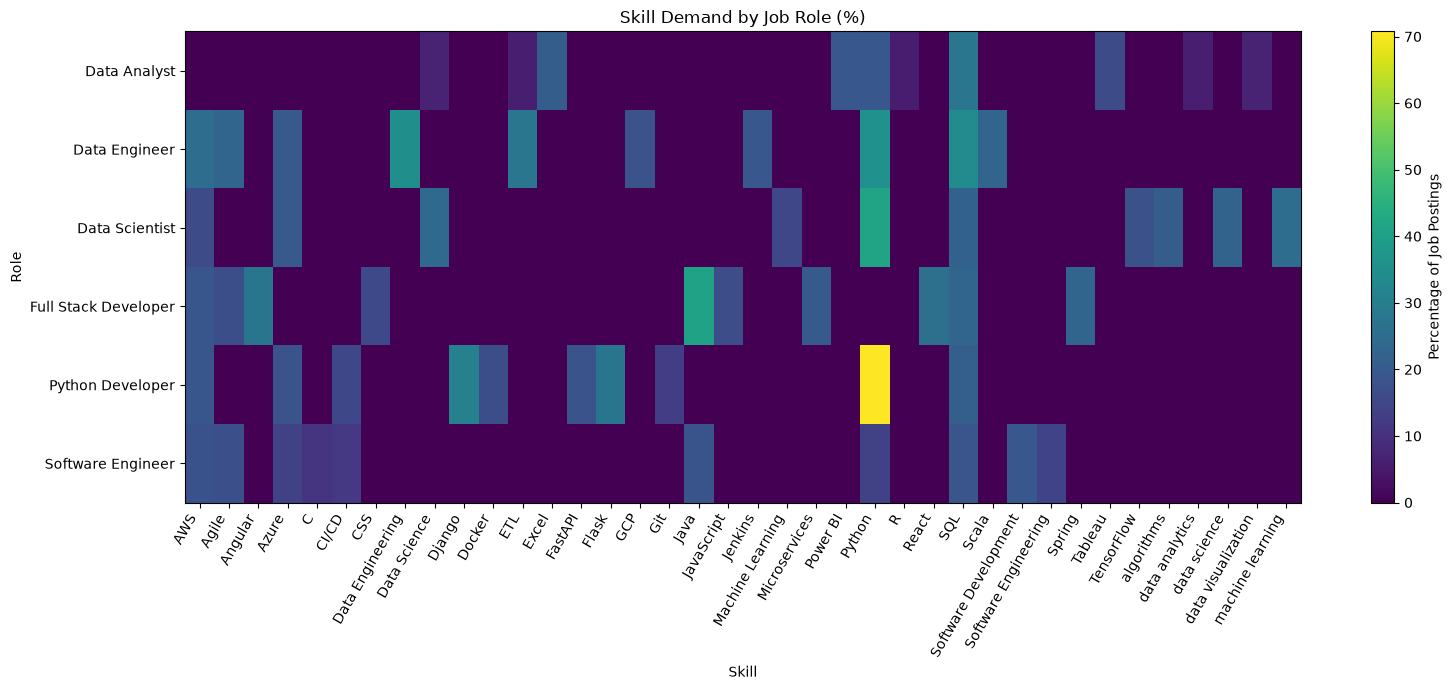

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 7))

plt.imshow(
    pivot.values,
    aspect="auto"
)

plt.xticks(
    range(len(pivot.columns)),
    pivot.columns,
    rotation=60,
    ha="right"
)

plt.yticks(
    range(len(pivot.index)),
    pivot.index
)

plt.xlabel("Skill")
plt.ylabel("Role")
plt.title("Skill Demand by Job Role (%)")

plt.colorbar(
    label="Percentage of Job Postings"
)

plt.tight_layout()
plt.show()

In [21]:
salary_query = """
SELECT
    job_id,
    title,
    minimum_salary,
    maximum_salary
FROM jobs
WHERE minimum_salary > 0
  AND maximum_salary > 0;
"""

salary_jobs = pd.read_sql(
    text(salary_query),
    engine
)

print("Jobs with salary:", len(salary_jobs))

Jobs with salary: 33136


In [22]:
salary_jobs["avg_salary"] = (
    salary_jobs["minimum_salary"]
    + salary_jobs["maximum_salary"]
) / 2

salary_jobs["avg_salary"].describe()

count    3.313600e+04
mean     7.573380e+05
std      1.026111e+06
min      7.860000e+02
25%      2.875000e+05
50%      4.250000e+05
75%      8.250000e+05
max      8.250000e+07
Name: avg_salary, dtype: float64

In [23]:
salary_roles = salary_jobs.merge(
    roles[["job_id", "role"]],
    on="job_id",
    how="left"
)

salary_by_role = (
    salary_roles
    .dropna(subset=["role"])
    .groupby("role")
    .agg(
        job_count=("job_id", "nunique"),
        avg_salary=("avg_salary", "mean"),
        median_salary=("avg_salary", "median")
    )
    .sort_values("median_salary", ascending=False)
)

salary_by_role

,job_count,avg_salary,median_salary
role,,,
Data Scientist,48,2.038021e+06,2137500.0
Data Engineer,319,1.814867e+06,2000000.0
Java Developer,152,1.662845e+06,1675000.0
Full Stack Developer,378,1.596500e+06,1650000.0
Cloud Engineer,18,1.590278e+06,1550000.0
DevOps Engineer,126,1.610218e+06,1500000.0
Software Engineer,111,1.650991e+06,1400000.0
Python Developer,61,1.388320e+06,1300000.0
Frontend Developer,65,1.588385e+06,1250000.0


In [24]:
skill_salary_query = """
SELECT
    s.skill_name,
    COUNT(DISTINCT j.job_id) AS job_count,
    AVG((j.minimum_salary + j.maximum_salary) / 2.0) AS avg_salary,
    PERCENTILE_CONT(0.5) WITHIN GROUP (
        ORDER BY (j.minimum_salary + j.maximum_salary) / 2.0
    ) AS median_salary
FROM jobs j
JOIN job_skills js
    ON j.job_id = js.job_id
JOIN skills s
    ON js.skill_id = s.skill_id
WHERE j.minimum_salary > 0
  AND j.maximum_salary > 0
GROUP BY s.skill_name
HAVING COUNT(DISTINCT j.job_id) >= 30
ORDER BY median_salary DESC;
"""

skill_salary = pd.read_sql(
    text(skill_salary_query),
    engine
)

print(skill_salary.shape)
skill_salary.head(30)

(129, 4)


,skill_name,job_count,avg_salary,median_salary
0,data integration,63,2.255952e+06,2500000.0
1,Generative AI,46,2.292391e+06,2362500.0
2,PyTorch,39,2.249308e+06,2250000.0
3,Golang,30,2.378267e+06,2250000.0
4,Databricks,77,1.918149e+06,2125000.0
5,machine learning,54,2.016315e+06,2087500.0
6,Machine Learning,56,2.082812e+06,2025000.0
7,IAM,31,2.100000e+06,2025000.0
8,Docker,245,1.968204e+06,2025000.0
9,ETL,252,1.906806e+06,2000000.0


In [25]:
skill_salary.head(20)

,skill_name,job_count,avg_salary,median_salary
0,data integration,63,2.255952e+06,2500000.0
1,Generative AI,46,2.292391e+06,2362500.0
2,PyTorch,39,2.249308e+06,2250000.0
3,Golang,30,2.378267e+06,2250000.0
4,Databricks,77,1.918149e+06,2125000.0
5,machine learning,54,2.016315e+06,2087500.0
6,Machine Learning,56,2.082812e+06,2025000.0
7,IAM,31,2.100000e+06,2025000.0
8,Docker,245,1.968204e+06,2025000.0
9,ETL,252,1.906806e+06,2000000.0


In [26]:
skill_market = skill_demand.merge(
    skill_salary,
    on="skill_name",
    how="inner"
)

skill_market = skill_market[
    skill_market["job_count_y"] >= 30
].copy()

skill_market = skill_market.sort_values(
    "job_count_x",
    ascending=False
)

skill_market.head(30)

,skill_name,job_count_x,demand_percent,job_count_y,avg_salary,median_salary
0,SAP,5606,5.74,753,1.147049e+06,775000.0
1,SQL,4164,4.26,817,1.599142e+06,1500000.0
2,Agile,3641,3.73,595,1.787776e+06,1925000.0
3,Python,3517,3.60,610,1.724569e+06,1500000.0
4,Java,3479,3.56,763,1.703840e+06,1875000.0
5,Azure,3422,3.50,664,1.877481e+06,1875000.0
6,Excel,3343,3.42,1118,5.709271e+05,362500.0
7,AWS,3297,3.38,690,1.870566e+06,2000000.0
8,Research,2335,2.39,645,7.812132e+05,450000.0
9,Software Development,2242,2.30,233,1.835826e+06,1700000.0


In [27]:
high_demand_high_salary = skill_market[
    (skill_market["job_count_x"] >= 500) &
    (skill_market["median_salary"] >= skill_market["median_salary"].median())
].sort_values(
    "median_salary",
    ascending=False
)

high_demand_high_salary.head(20)

,skill_name,job_count_x,demand_percent,job_count_y,avg_salary,median_salary
22,Docker,1221,1.25,245,1.968204e+06,2025000.0
7,AWS,3297,3.38,690,1.870566e+06,2000000.0
44,Terraform,572,0.59,86,2.026599e+06,2000000.0
14,Microservices,1555,1.59,327,2.015306e+06,2000000.0
36,Kafka,783,0.80,220,2.134432e+06,2000000.0
28,ETL,1058,1.08,252,1.906806e+06,2000000.0
16,Kubernetes,1398,1.43,247,1.945457e+06,2000000.0
37,Data Engineering,720,0.74,173,2.088410e+06,2000000.0
35,GitHub,808,0.83,217,1.798053e+06,1925000.0
2,Agile,3641,3.73,595,1.787776e+06,1925000.0


In [28]:
print("Demand median:",
      skill_market["job_count_x"].median())

print("Demand 75th percentile:",
      skill_market["job_count_x"].quantile(0.75))

print("Salary median:",
      skill_market["median_salary"].median())

Demand median: 391.0
Demand 75th percentile: 873.0
Salary median: 1650000.0


In [29]:
demand_threshold = skill_market["job_count_x"].quantile(0.75)
salary_threshold = skill_market["median_salary"].median()

sweet_spot = skill_market[
    (skill_market["job_count_x"] >= demand_threshold) &
    (skill_market["median_salary"] >= salary_threshold)
].copy()

sweet_spot = sweet_spot.sort_values(
    "median_salary",
    ascending=False
)

sweet_spot[
    [
        "skill_name",
        "job_count_x",
        "demand_percent",
        "job_count_y",
        "median_salary"
    ]
]

,skill_name,job_count_x,demand_percent,job_count_y,median_salary
22,Docker,1221,1.25,245,2025000.0
28,ETL,1058,1.08,252,2000000.0
7,AWS,3297,3.38,690,2000000.0
16,Kubernetes,1398,1.43,247,2000000.0
14,Microservices,1555,1.59,327,2000000.0
2,Agile,3641,3.73,595,1925000.0
27,Jira,1093,1.12,239,1925000.0
25,Scrum,1153,1.18,248,1925000.0
4,Java,3479,3.56,763,1875000.0
26,Jenkins,1096,1.12,315,1875000.0


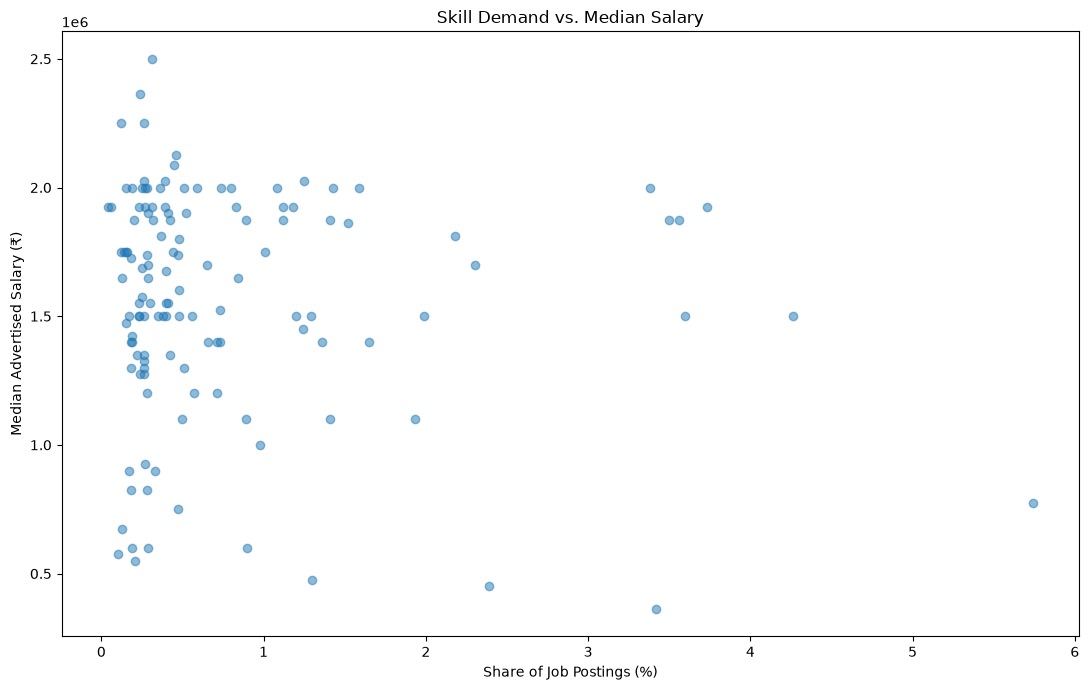

In [30]:
plt.figure(figsize=(11, 7))

plt.scatter(
    skill_market["demand_percent"],
    skill_market["median_salary"],
    alpha=0.5
)

plt.xlabel("Share of Job Postings (%)")
plt.ylabel("Median Advertised Salary (₹)")
plt.title("Skill Demand vs. Median Salary")

plt.tight_layout()
plt.show()

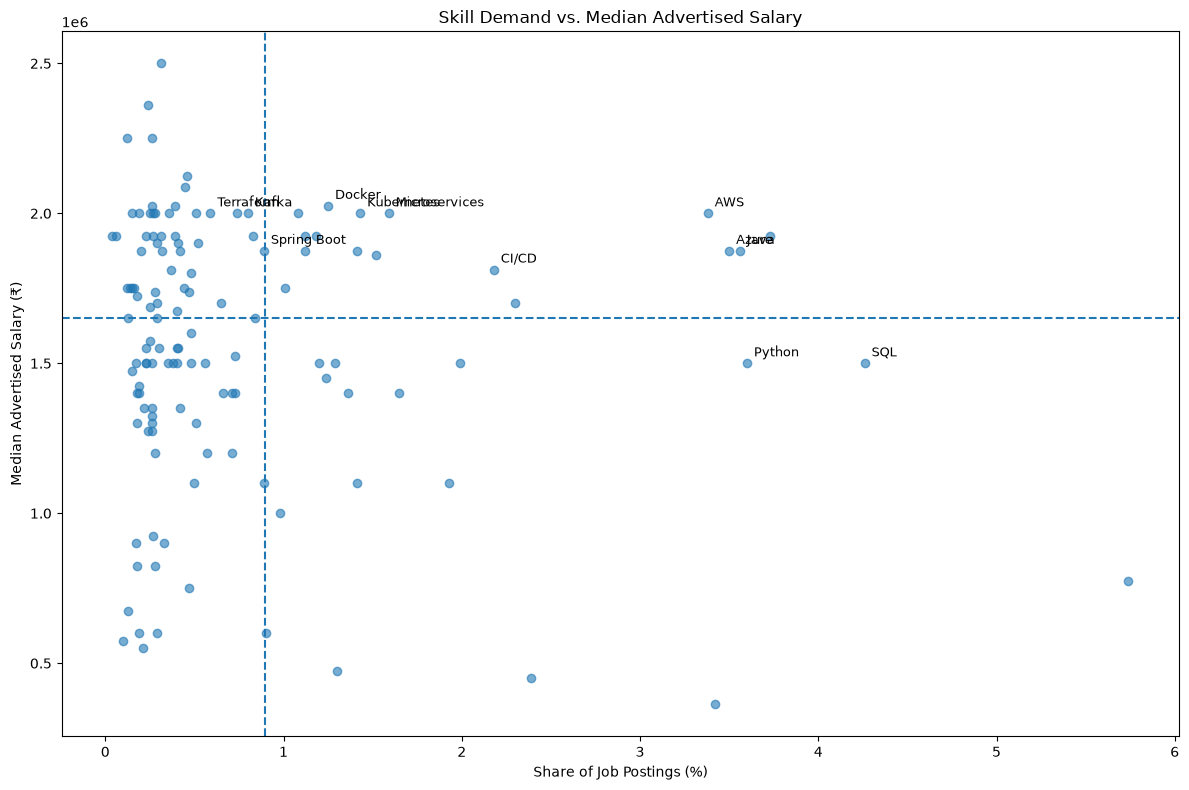

In [31]:
import matplotlib.pyplot as plt

# Calculate thresholds
demand_threshold = skill_market["job_count_x"].quantile(0.75)
salary_threshold = skill_market["median_salary"].median()

plt.figure(figsize=(12, 8))

plt.scatter(
    skill_market["demand_percent"],
    skill_market["median_salary"],
    alpha=0.6
)

# Threshold lines
plt.axvline(
    demand_threshold / 97679 * 100,
    linestyle="--"
)

plt.axhline(
    salary_threshold,
    linestyle="--"
)

# Skills we want to highlight
highlight_skills = [
    "Python",
    "SQL",
    "Java",
    "AWS",
    "Azure",
    "Docker",
    "Kubernetes",
    "Kafka",
    "Terraform",
    "Spring Boot",
    "Microservices",
    "CI/CD"
]

for _, row in skill_market[
    skill_market["skill_name"].isin(highlight_skills)
].iterrows():

    plt.annotate(
        row["skill_name"],
        (
            row["demand_percent"],
            row["median_salary"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Share of Job Postings (%)")
plt.ylabel("Median Advertised Salary (₹)")
plt.title("Skill Demand vs. Median Advertised Salary")

plt.tight_layout()
plt.show()

In [32]:
demand_threshold = skill_market["demand_percent"].quantile(0.75)
salary_threshold = skill_market["median_salary"].median()

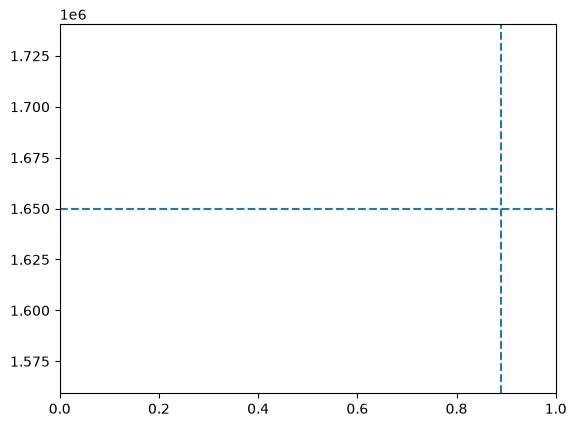

In [33]:
plt.axvline(demand_threshold, linestyle="--")
plt.axhline(salary_threshold, linestyle="--")

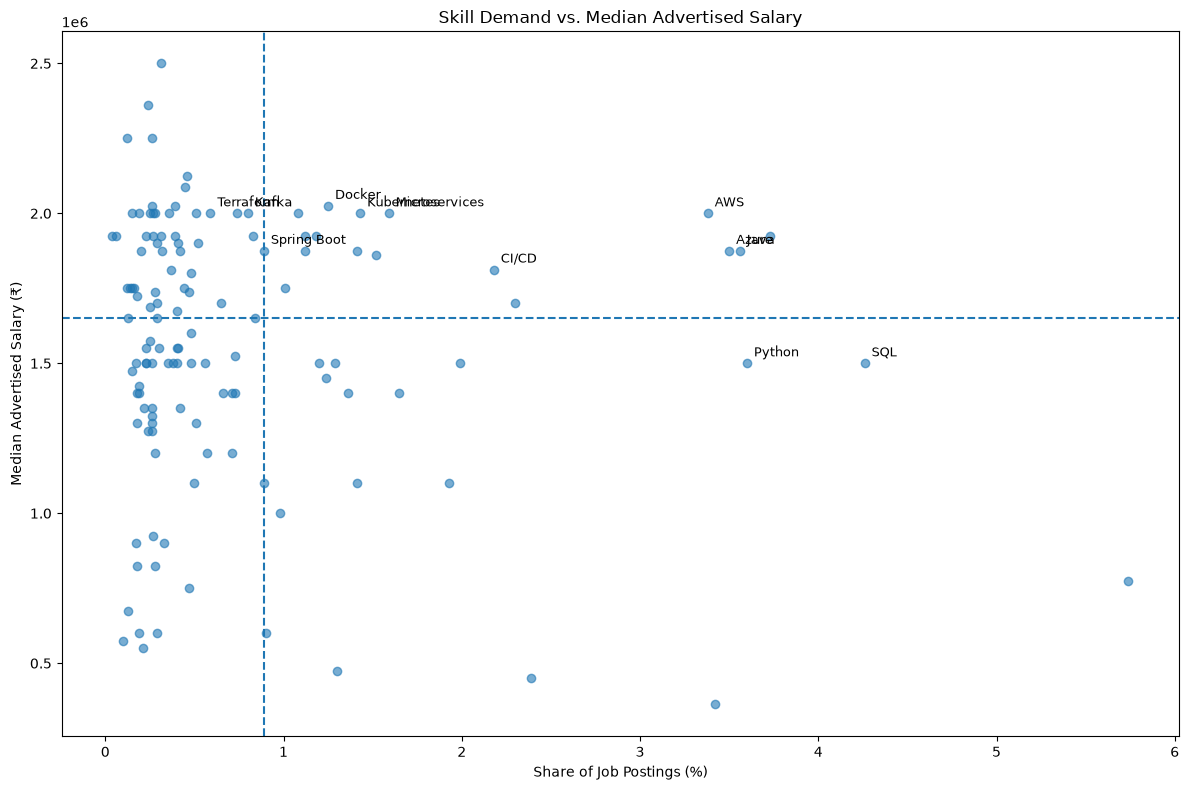

In [34]:
import matplotlib.pyplot as plt

demand_threshold = skill_market["demand_percent"].quantile(0.75)
salary_threshold = skill_market["median_salary"].median()

plt.figure(figsize=(12, 8))

plt.scatter(
    skill_market["demand_percent"],
    skill_market["median_salary"],
    alpha=0.6
)

plt.axvline(demand_threshold, linestyle="--")
plt.axhline(salary_threshold, linestyle="--")

highlight_skills = [
    "Python",
    "SQL",
    "Java",
    "AWS",
    "Azure",
    "Docker",
    "Kubernetes",
    "Kafka",
    "Terraform",
    "Spring Boot",
    "Microservices",
    "CI/CD"
]

for _, row in skill_market[
    skill_market["skill_name"].isin(highlight_skills)
].iterrows():

    plt.annotate(
        row["skill_name"],
        (row["demand_percent"], row["median_salary"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Share of Job Postings (%)")
plt.ylabel("Median Advertised Salary (₹)")
plt.title("Skill Demand vs. Median Advertised Salary")

plt.tight_layout()
plt.show()

In [35]:
sweet_spot = skill_market[
    (skill_market["demand_percent"] >= demand_threshold) &
    (skill_market["median_salary"] >= salary_threshold)
].copy()

sweet_spot = sweet_spot.sort_values(
    ["median_salary", "demand_percent"],
    ascending=[False, False]
)

sweet_spot[
    [
        "skill_name",
        "demand_percent",
        "job_count_x",
        "job_count_y",
        "median_salary"
    ]
]

,skill_name,demand_percent,job_count_x,job_count_y,median_salary
22,Docker,1.25,1221,245,2025000.0
7,AWS,3.38,3297,690,2000000.0
14,Microservices,1.59,1555,327,2000000.0
16,Kubernetes,1.43,1398,247,2000000.0
28,ETL,1.08,1058,252,2000000.0
2,Agile,3.73,3641,595,1925000.0
25,Scrum,1.18,1153,248,1925000.0
27,Jira,1.12,1093,239,1925000.0
4,Java,3.56,3479,763,1875000.0
5,Azure,3.50,3422,664,1875000.0


In [36]:
sweet_spot["market_score"] = (
    sweet_spot["demand_percent"].rank(pct=True) * 0.5
    +
    sweet_spot["median_salary"].rank(pct=True) * 0.5
)

sweet_spot = sweet_spot.sort_values(
    "market_score",
    ascending=False
)

sweet_spot[
    [
        "skill_name",
        "demand_percent",
        "median_salary",
        "market_score"
    ]
].head(20)

,skill_name,demand_percent,median_salary,market_score
7,AWS,3.38,2000000.0,0.838235
2,Agile,3.73,1925000.0,0.823529
14,Microservices,1.59,2000000.0,0.750000
22,Docker,1.25,2025000.0,0.705882
16,Kubernetes,1.43,2000000.0,0.691176
4,Java,3.56,1875000.0,0.676471
5,Azure,3.50,1875000.0,0.647059
28,ETL,1.08,2000000.0,0.514706
25,Scrum,1.18,1925000.0,0.500000
27,Jira,1.12,1925000.0,0.455882


In [37]:
combination_query = """
SELECT
    COUNT(DISTINCT j.job_id) AS job_count,
    AVG((j.minimum_salary + j.maximum_salary) / 2.0) AS avg_salary,
    PERCENTILE_CONT(0.5) WITHIN GROUP (
        ORDER BY (j.minimum_salary + j.maximum_salary) / 2.0
    ) AS median_salary
FROM jobs j
WHERE j.minimum_salary > 0
  AND j.maximum_salary > 0
  AND EXISTS (
      SELECT 1
      FROM job_skills js
      JOIN skills s ON js.skill_id = s.skill_id
      WHERE js.job_id = j.job_id
        AND LOWER(s.skill_name) = 'python'
  )
  AND EXISTS (
      SELECT 1
      FROM job_skills js
      JOIN skills s ON js.skill_id = s.skill_id
      WHERE js.job_id = j.job_id
        AND LOWER(s.skill_name) = 'aws'
  );
"""

python_aws = pd.read_sql(
    text(combination_query),
    engine
)

python_aws

,job_count,avg_salary,median_salary
0,153,1.861830e+06,1700000.0


In [38]:
python_query = """
SELECT
    COUNT(DISTINCT j.job_id) AS job_count,
    AVG((j.minimum_salary + j.maximum_salary) / 2.0) AS avg_salary,
    PERCENTILE_CONT(0.5) WITHIN GROUP (
        ORDER BY (j.minimum_salary + j.maximum_salary) / 2.0
    ) AS median_salary
FROM jobs j
WHERE j.minimum_salary > 0
  AND j.maximum_salary > 0
  AND EXISTS (
      SELECT 1
      FROM job_skills js
      JOIN skills s ON js.skill_id = s.skill_id
      WHERE js.job_id = j.job_id
        AND LOWER(s.skill_name) = 'python'
  );
"""

python_salary = pd.read_sql(
    text(python_query),
    engine
)

python_salary

,job_count,avg_salary,median_salary
0,622,1.719063e+06,1500000.0


In [39]:
skill_pairs = [
    ("Python", "AWS"),
    ("Python", "SQL"),
    ("Python", "Docker"),
    ("AWS", "Docker"),
    ("AWS", "Kubernetes"),
    ("Java", "Spring"),
    ("Java", "Spring Boot"),
    ("SQL", "Power BI"),
    ("JavaScript", "React"),
    ("AWS", "Terraform")
]

results = []

for skill1, skill2 in skill_pairs:

    query = text("""
        SELECT
            COUNT(DISTINCT j.job_id) AS job_count,
            AVG(
                (j.minimum_salary + j.maximum_salary) / 2.0
            ) AS avg_salary,
            PERCENTILE_CONT(0.5) WITHIN GROUP (
                ORDER BY
                (j.minimum_salary + j.maximum_salary) / 2.0
            ) AS median_salary
        FROM jobs j
        WHERE j.minimum_salary > 0
          AND j.maximum_salary > 0

          AND EXISTS (
              SELECT 1
              FROM job_skills js
              JOIN skills s
                ON js.skill_id = s.skill_id
              WHERE js.job_id = j.job_id
                AND LOWER(s.skill_name) = LOWER(:skill1)
          )

          AND EXISTS (
              SELECT 1
              FROM job_skills js
              JOIN skills s
                ON js.skill_id = s.skill_id
              WHERE js.job_id = j.job_id
                AND LOWER(s.skill_name) = LOWER(:skill2)
          );
    """)

    result = pd.read_sql(
        query,
        engine,
        params={
            "skill1": skill1,
            "skill2": skill2
        }
    )

    results.append({
        "skill_1": skill1,
        "skill_2": skill2,
        "job_count": result.loc[0, "job_count"],
        "avg_salary": result.loc[0, "avg_salary"],
        "median_salary": result.loc[0, "median_salary"]
    })

skill_combinations = pd.DataFrame(results)

skill_combinations

,skill_1,skill_2,job_count,avg_salary,median_salary
0,Python,AWS,153,1.861830e+06,1700000.0
1,Python,SQL,203,1.689877e+06,1550000.0
2,Python,Docker,78,1.690160e+06,1500000.0
3,AWS,Docker,151,1.999007e+06,2250000.0
4,AWS,Kubernetes,133,2.096805e+06,2500000.0
5,Java,Spring,283,1.688913e+06,1875000.0
6,Java,Spring Boot,242,1.728048e+06,1875000.0
7,SQL,Power BI,45,1.396611e+06,1250000.0
8,JavaScript,React,97,1.706639e+06,1500000.0
9,AWS,Terraform,49,1.993622e+06,2000000.0


In [40]:
skill_combinations["avg_salary_lpa"] = (
    skill_combinations["avg_salary"] / 100000
).round(2)

skill_combinations["median_salary_lpa"] = (
    skill_combinations["median_salary"] / 100000
).round(2)

skill_combinations = skill_combinations.sort_values(
    "median_salary",
    ascending=False
)

skill_combinations[
    [
        "skill_1",
        "skill_2",
        "job_count",
        "avg_salary_lpa",
        "median_salary_lpa"
    ]
]

,skill_1,skill_2,job_count,avg_salary_lpa,median_salary_lpa
4,AWS,Kubernetes,133,20.97,25.00
3,AWS,Docker,151,19.99,22.50
9,AWS,Terraform,49,19.94,20.00
5,Java,Spring,283,16.89,18.75
6,Java,Spring Boot,242,17.28,18.75
0,Python,AWS,153,18.62,17.00
1,Python,SQL,203,16.90,15.50
2,Python,Docker,78,16.90,15.00
8,JavaScript,React,97,17.07,15.00
7,SQL,Power BI,45,13.97,12.50


In [41]:
# Individual skill median salaries
individual_medians = (
    skill_salary[
        skill_salary["skill_name"].isin(
            set(skill_combinations["skill_1"]) |
            set(skill_combinations["skill_2"])
        )
    ][["skill_name", "median_salary"]]
    .copy()
)

individual_medians["median_salary_lpa"] = (
    individual_medians["median_salary"] / 100000
).round(2)

individual_medians

,skill_name,median_salary,median_salary_lpa
8,Docker,2025000.0,20.25
18,AWS,2000000.0,20.00
20,Kubernetes,2000000.0,20.00
22,Terraform,2000000.0,20.00
36,Java,1875000.0,18.75
37,Spring,1875000.0,18.75
38,Spring Boot,1875000.0,18.75
71,Power BI,1525000.0,15.25
74,React,1500000.0,15.00
80,Python,1500000.0,15.00


In [42]:
premium_results = []

for _, row in skill_combinations.iterrows():

    skill1 = row["skill_1"]
    skill2 = row["skill_2"]

    salary1 = individual_medians.loc[
        individual_medians["skill_name"].str.lower() == skill1.lower(),
        "median_salary_lpa"
    ]

    salary2 = individual_medians.loc[
        individual_medians["skill_name"].str.lower() == skill2.lower(),
        "median_salary_lpa"
    ]

    if len(salary1) == 0 or len(salary2) == 0:
        continue

    baseline = (salary1.iloc[0] + salary2.iloc[0]) / 2

    combination_salary = row["median_salary_lpa"]

    premium = combination_salary - baseline
    premium_percent = (premium / baseline) * 100

    premium_results.append({
        "skill_1": skill1,
        "skill_2": skill2,
        "combination_median_lpa": combination_salary,
        "individual_baseline_lpa": round(baseline, 2),
        "premium_lpa": round(premium, 2),
        "premium_percent": round(premium_percent, 2),
        "job_count": row["job_count"]
    })

skill_premiums = pd.DataFrame(premium_results)

skill_premiums.sort_values(
    "premium_percent",
    ascending=False
)

,skill_1,skill_2,combination_median_lpa,individual_baseline_lpa,premium_lpa,premium_percent,job_count
0,AWS,Kubernetes,25.00,20.00,5.00,25.00,133
1,AWS,Docker,22.50,20.12,2.38,11.80,151
8,JavaScript,React,15.00,14.50,0.50,3.45,97
6,Python,SQL,15.50,15.00,0.50,3.33,203
2,AWS,Terraform,20.00,20.00,0.00,0.00,49
3,Java,Spring,18.75,18.75,0.00,0.00,283
4,Java,Spring Boot,18.75,18.75,0.00,0.00,242
5,Python,AWS,17.00,17.50,-0.50,-2.86,153
7,Python,Docker,15.00,17.62,-2.62,-14.89,78
9,SQL,Power BI,12.50,15.12,-2.62,-17.36,45


In [43]:
print(skill_salary.columns)

Index(['skill_name', 'job_count', 'avg_salary', 'median_salary'], dtype='str')


In [44]:
# Create a simple lookup: skill → median salary in LPA

median_lookup = (
    skill_salary
    .set_index("skill_name")["median_salary"]
    .to_dict()
)

premium_results = []

for _, row in skill_combinations.iterrows():

    skill1 = row["skill_1"]
    skill2 = row["skill_2"]

    salary1 = median_lookup.get(skill1)
    salary2 = median_lookup.get(skill2)

    if salary1 is None or salary2 is None:
        continue

    # Average salary of the two individual skills
    baseline = (salary1 + salary2) / 2

    combination_salary = row["median_salary"]

    premium = combination_salary - baseline
    premium_percent = (premium / baseline) * 100

    premium_results.append({
        "skill_1": skill1,
        "skill_2": skill2,
        "job_count": row["job_count"],
        "combination_median_lpa": round(
            combination_salary / 100000, 2
        ),
        "individual_baseline_lpa": round(
            baseline / 100000, 2
        ),
        "premium_lpa": round(
            premium / 100000, 2
        ),
        "premium_percent": round(
            premium_percent, 2
        )
    })

skill_premiums = pd.DataFrame(premium_results)

skill_premiums.sort_values(
    "premium_percent",
    ascending=False
)

,skill_1,skill_2,job_count,combination_median_lpa,individual_baseline_lpa,premium_lpa,premium_percent
0,AWS,Kubernetes,133,25.00,20.00,5.00,25.00
1,AWS,Docker,151,22.50,20.12,2.38,11.80
8,JavaScript,React,97,15.00,14.50,0.50,3.45
6,Python,SQL,203,15.50,15.00,0.50,3.33
2,AWS,Terraform,49,20.00,20.00,0.00,0.00
3,Java,Spring,283,18.75,18.75,0.00,0.00
4,Java,Spring Boot,242,18.75,18.75,0.00,0.00
5,Python,AWS,153,17.00,17.50,-0.50,-2.86
7,Python,Docker,78,15.00,17.62,-2.62,-14.89
9,SQL,Power BI,45,12.50,15.12,-2.62,-17.36


In [45]:
skill_premiums[
    [
        "skill_1",
        "skill_2",
        "job_count",
        "combination_median_lpa",
        "individual_baseline_lpa",
        "premium_lpa",
        "premium_percent"
    ]
]

,skill_1,skill_2,job_count,combination_median_lpa,individual_baseline_lpa,premium_lpa,premium_percent
0,AWS,Kubernetes,133,25.00,20.00,5.00,25.00
1,AWS,Docker,151,22.50,20.12,2.38,11.80
2,AWS,Terraform,49,20.00,20.00,0.00,0.00
3,Java,Spring,283,18.75,18.75,0.00,0.00
4,Java,Spring Boot,242,18.75,18.75,0.00,0.00
5,Python,AWS,153,17.00,17.50,-0.50,-2.86
6,Python,SQL,203,15.50,15.00,0.50,3.33
7,Python,Docker,78,15.00,17.62,-2.62,-14.89
8,JavaScript,React,97,15.00,14.50,0.50,3.45
9,SQL,Power BI,45,12.50,15.12,-2.62,-17.36


In [46]:
location_query = """
SELECT
    job_id,
    title,
    location,
    minimum_salary,
    maximum_salary
FROM jobs
WHERE location IS NOT NULL;
"""

location_jobs = pd.read_sql(
    text(location_query),
    engine
)

print(location_jobs.shape)
location_jobs.head()

(97679, 5)


,job_id,title,location,minimum_salary,maximum_salary
0,270925008041,Sr. HR Recruiter (NON IT),Kolkata(Chinar Park),200000.0,400000.0
1,270925007584,Fire And Safety Officer,"Gandhinagar, Ahmedabad",300000.0,500000.0
2,270925007492,Opening For Performance Marketing - Chennai,Chennai,NaN,NaN
3,270925007443,Medical Billing Executive,"Mohali, Chandigarh, Kharar, Zirakpur",70000.0,200000.0
4,270925007430,Senior Group Product Manager - CNS Therapy,Ahmedabad,800000.0,1800000.0


In [47]:
location_counts = (
    location_jobs["location"]
    .value_counts()
    .head(30)
)

location_counts

location
Bengaluru                                 16783
Hyderabad                                  7657
Pune                                       6096
Chennai                                    4418
Gurugram                                   4226
Mumbai                                     4149
Noida                                      2688
Remote                                     1952
Ahmedabad                                  1721
Navi Mumbai                                1451
Kolkata                                    1047
Hyderabad, Chennai, Bengaluru              1037
Hybrid - Bengaluru                          943
Jaipur                                      815
Coimbatore                                  618
Hybrid - Hyderabad                          575
Kochi                                       526
Vadodara                                    526
Hybrid - Pune                               478
Thane                                       408
Surat                          

In [48]:
location_jobs["city"] = (
    location_jobs["location"]
    .str.split(",")
    .str[0]
    .str.strip()
)

In [49]:
location_jobs["city"] = (
    location_jobs["city"]
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.strip()
)

In [50]:
top_cities = (
    location_jobs["city"]
    .value_counts()
    .head(20)
)

top_cities

city
Bengaluru             18320
Hyderabad             10899
Pune                   8405
Mumbai                 6478
Chennai                6099
Gurugram               5002
Noida                  4627
Ahmedabad              2377
Remote                 1952
Kolkata                1794
Navi Mumbai            1673
Hybrid - Hyderabad     1434
Hybrid - Bengaluru     1106
Thane                  1008
Hybrid - Pune           973
Jaipur                  966
Kochi                   907
Mumbai Suburban         765
Coimbatore              725
Mohali                  612
Name: count, dtype: int64

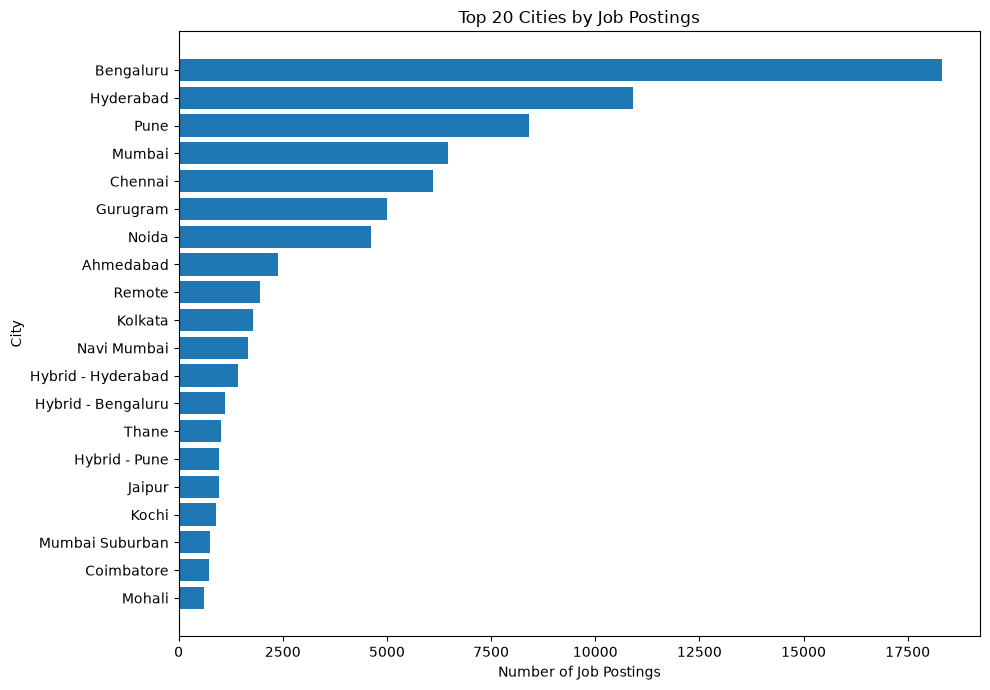

In [51]:
import matplotlib.pyplot as plt

top_cities_plot = top_cities.sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    top_cities_plot.index,
    top_cities_plot.values
)

plt.xlabel("Number of Job Postings")
plt.ylabel("City")
plt.title("Top 20 Cities by Job Postings")

plt.tight_layout()
plt.show()

In [52]:
location_jobs["city_clean"] = location_jobs["city"].copy()

location_jobs["city_clean"] = (
    location_jobs["city_clean"]
    .str.replace(
        r"^Hybrid\s*-\s*",
        "",
        regex=True,
        case=False
    )
    .str.strip()
)

In [53]:
location_jobs["city_clean"].value_counts().head(25)

city_clean
Bengaluru          19426
Hyderabad          12333
Pune                9378
Mumbai              6632
Chennai             6425
Gurugram            5259
Noida               4979
Ahmedabad           2436
Kolkata             1962
Remote              1952
Navi Mumbai         1701
Thane               1029
Kochi                980
Jaipur               968
Mumbai Suburban      787
Coimbatore           750
Chandigarh           625
Mohali               616
Vadodara             590
Nagpur               584
Surat                501
Lucknow              477
Nashik               461
New Delhi            455
Faridabad            374
Name: count, dtype: int64

In [54]:
salary_location = location_jobs[
    (location_jobs["minimum_salary"] > 0) &
    (location_jobs["maximum_salary"] > 0)
].copy()

salary_location["avg_salary"] = (
    salary_location["minimum_salary"]
    + salary_location["maximum_salary"]
) / 2

In [55]:
city_salary = (
    salary_location
    .groupby("city_clean")
    .agg(
        job_count=("job_id", "nunique"),
        avg_salary=("avg_salary", "mean"),
        median_salary=("avg_salary", "median")
    )
    .query("job_count >= 30")
    .sort_values("median_salary", ascending=False)
)

city_salary

,job_count,avg_salary,median_salary
city_clean,,,
Dahej,36,1.462847e+06,962500.0
Bareilly,39,2.149295e+06,750000.0
Karimnagar,33,9.409091e+05,725000.0
Remote,775,1.001040e+06,600000.0
Bhopal,44,8.664773e+05,575000.0
...,...,...,...
Lucknow,233,4.927017e+05,287500.0
Thrissur,42,3.892143e+05,287500.0
Goregaon,31,5.251290e+05,275000.0


In [56]:
city_salary["avg_salary_lpa"] = (
    city_salary["avg_salary"] / 100000
).round(2)

city_salary["median_salary_lpa"] = (
    city_salary["median_salary"] / 100000
).round(2)

city_salary[
    [
        "job_count",
        "avg_salary_lpa",
        "median_salary_lpa"
    ]
]

,job_count,avg_salary_lpa,median_salary_lpa
city_clean,,,
Dahej,36,14.63,9.62
Bareilly,39,21.49,7.50
Karimnagar,33,9.41,7.25
Remote,775,10.01,6.00
Bhopal,44,8.66,5.75
...,...,...,...
Lucknow,233,4.93,2.88
Thrissur,42,3.89,2.88
Goregaon,31,5.25,2.75


In [57]:
major_city_salary = (
    city_salary[
        city_salary["job_count"] >= 100
    ]
    .sort_values(
        "median_salary_lpa",
        ascending=False
    )
)

major_city_salary[
    [
        "job_count",
        "avg_salary_lpa",
        "median_salary_lpa"
    ]
]

,job_count,avg_salary_lpa,median_salary_lpa
city_clean,,,
Remote,775,10.01,6.00
Hyderabad,3165,9.97,5.50
Aurangabad,173,5.93,5.25
Pune,2725,8.30,5.00
Bengaluru,3674,8.99,4.75
Bangalore Rural,132,7.32,4.75
Gurugram,1867,7.80,4.50
Navi Mumbai,499,7.22,4.25
New Delhi,286,6.68,4.25


In [58]:
city_demand = (
    location_jobs["city_clean"]
    .value_counts()
    .reset_index()
)

city_demand.columns = ["city", "job_count"]

city_demand.head(20)

,city,job_count
0,Bengaluru,19426
1,Hyderabad,12333
2,Pune,9378
3,Mumbai,6632
4,Chennai,6425
5,Gurugram,5259
6,Noida,4979
7,Ahmedabad,2436
8,Kolkata,1962
9,Remote,1952


In [59]:
city_roles = location_jobs[
    ["job_id", "city_clean"]
].merge(
    roles[["job_id", "role"]],
    on="job_id",
    how="inner"
)

city_roles = city_roles.dropna(subset=["role"])

print(city_roles.shape)

(9588, 3)


In [60]:
city_role_counts = (
    city_roles
    .groupby(["city_clean", "role"])
    .size()
    .reset_index(name="job_count")
)

city_role_counts.head(20)

,city_clean,role,job_count
0,Adilabad,Data Engineer,5
1,Adilabad,DevOps Engineer,1
2,Adilabad,Full Stack Developer,1
3,Agra,DevOps Engineer,2
4,Ahmedabad,Backend Developer,4
5,Ahmedabad,Business Analyst,21
6,Ahmedabad,Data Analyst,6
7,Ahmedabad,Data Engineer,6
8,Ahmedabad,Data Scientist,9
9,Ahmedabad,DevOps Engineer,8


In [61]:
major_cities = [
    "Bengaluru",
    "Hyderabad",
    "Pune",
    "Mumbai",
    "Chennai",
    "Gurugram",
    "Noida",
    "Ahmedabad",
    "Kolkata",
    "Kochi"
]

major_city_roles = city_role_counts[
    city_role_counts["city_clean"].isin(major_cities)
]

In [62]:
top_city_roles = (
    major_city_roles
    .sort_values(
        ["city_clean", "job_count"],
        ascending=[True, False]
    )
    .groupby("city_clean")
    .head(5)
)

top_city_roles

,city_clean,role,job_count
15,Ahmedabad,QA / Testing,28
5,Ahmedabad,Business Analyst,21
11,Ahmedabad,Full Stack Developer,18
13,Ahmedabad,Project Manager,15
8,Ahmedabad,Data Scientist,9
77,Bengaluru,Software Engineer,568
71,Bengaluru,Full Stack Developer,355
75,Bengaluru,QA / Testing,246
67,Bengaluru,Data Engineer,216
69,Bengaluru,DevOps Engineer,177


In [63]:
city_totals = (
    city_roles
    .groupby("city_clean")["job_id"]
    .nunique()
    .reset_index(name="city_job_count")
)

city_role_share = city_role_counts.merge(
    city_totals,
    on="city_clean",
    how="left"
)

city_role_share["role_share_percent"] = (
    city_role_share["job_count"]
    / city_role_share["city_job_count"]
    * 100
).round(2)


In [64]:
city_role_share_major = city_role_share[
    city_role_share["city_clean"].isin(major_cities)
]

In [65]:
top_city_role_share = (
    city_role_share_major
    .sort_values(
        ["city_clean", "role_share_percent"],
        ascending=[True, False]
    )
    .groupby("city_clean")
    .head(5)
)

top_city_role_share

,city_clean,role,job_count,city_job_count,role_share_percent
15,Ahmedabad,QA / Testing,28,134,20.90
5,Ahmedabad,Business Analyst,21,134,15.67
11,Ahmedabad,Full Stack Developer,18,134,13.43
13,Ahmedabad,Project Manager,15,134,11.19
8,Ahmedabad,Data Scientist,9,134,6.72
77,Bengaluru,Software Engineer,568,2441,23.27
71,Bengaluru,Full Stack Developer,355,2441,14.54
75,Bengaluru,QA / Testing,246,2441,10.08
67,Bengaluru,Data Engineer,216,2441,8.85
69,Bengaluru,DevOps Engineer,177,2441,7.25


In [66]:
city_skill_query = """
SELECT
    j.job_id,
    j.location,
    s.skill_name
FROM jobs j
JOIN job_skills js
    ON j.job_id = js.job_id
JOIN skills s
    ON js.skill_id = s.skill_id;
"""

city_skills = pd.read_sql(
    text(city_skill_query),
    engine
)

print(city_skills.shape)
city_skills.head()

(112130, 3)


,job_id,location,skill_name
0,270925006315,"New Delhi, Gurugram, Greater Noida",Python
1,270925000088,Varanasi,AWS
2,270525026436,Noida,Excel
3,270225007394,"Jalandhar, Noida, Gurugram",Research
4,260925914626,Thane,Linux


In [67]:
city_skills["city"] = (
    city_skills["location"]
    .str.split(",")
    .str[0]
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.replace(
        r"^Hybrid\s*-\s*",
        "",
        regex=True,
        case=False
    )
    .str.strip()
)

In [68]:
city_skills["city"].value_counts().head(20)

city
Bengaluru             30230
Hyderabad             20656
Pune                  14508
Chennai                8045
Noida                  6187
Gurugram               5246
Mumbai                 5076
Remote                 3656
Kolkata                1645
Kochi                  1449
Ahmedabad              1329
Navi Mumbai             806
Coimbatore              646
Thane                   429
Chandigarh              422
Mohali                  410
Jaipur                  386
Thiruvananthapuram      357
Mumbai Suburban         326
Vadodara                280
Name: count, dtype: int64

In [69]:
city_skill_counts = (
    city_skills
    .groupby(["city", "skill_name"])["job_id"]
    .nunique()
    .reset_index(name="job_count")
)

city_skill_counts.head(20)

,city,skill_name,job_count
0,Achampet,SAP,1
1,Adampur,Optimization,1
2,Adampur,Research,1
3,Adilabad,AWS,4
4,Adilabad,Agile,5
5,Adilabad,Airflow,2
6,Adilabad,Ansible,4
7,Adilabad,Azure,3
8,Adilabad,C,1
9,Adilabad,CI/CD,1


In [70]:
major_city_skills = city_skill_counts[
    city_skill_counts["city"].isin(major_cities)
]

In [71]:
top_city_skills = (
    major_city_skills
    .sort_values(
        ["city", "job_count"],
        ascending=[True, False]
    )
    .groupby("city")
    .head(10)
)

top_city_skills

,city,skill_name,job_count
125,Ahmedabad,Excel,96
211,Ahmedabad,SAP,86
209,Ahmedabad,Research,71
184,Ahmedabad,Optimization,54
178,Ahmedabad,Networking,42
...,...,...,...
7620,Pune,Azure,473
7604,Pune,AWS,434
7693,Pune,Excel,317
7642,Pune,CI/CD,307


In [74]:
date_query = """
SELECT
    job_id,
    job_uploaded
FROM jobs;
"""

job_dates = pd.read_sql(
    text(date_query),
    engine
)

print(job_dates.columns)
print(job_dates.head(10))

Index(['job_id', 'job_uploaded'], dtype='str')
         job_id job_uploaded
0  270925008041         None
1  270925007584         None
2  270925007492         None
3  270925007443         None
4  270925007430         None
5  270925007323         None
6  270925007180         None
7  270925006659         None
8  270925006525         None
9  270925006315         None


In [75]:
date_query = """
SELECT
    job_id,
    job_uploaded
FROM jobs;
"""

job_dates = pd.read_sql(
    text(date_query),
    engine
)

print(job_dates.columns)
print(job_dates.head(10))

Index(['job_id', 'job_uploaded'], dtype='str')
         job_id job_uploaded
0  270925008041         None
1  270925007584         None
2  270925007492         None
3  270925007443         None
4  270925007430         None
5  270925007323         None
6  270925007180         None
7  270925006659         None
8  270925006525         None
9  270925006315         None


In [77]:
from sqlalchemy import text
import pandas as pd

# Get upload dates from PostgreSQL
date_query = """
SELECT
    job_id,
    job_uploaded
FROM jobs;
"""

job_dates = pd.read_sql(
    text(date_query),
    engine
)

# Convert to datetime
job_dates["job_date"] = pd.to_datetime(
    job_dates["job_uploaded"],
    errors="coerce"
)

print("Total jobs:", len(job_dates))
print("Valid dates:", job_dates["job_date"].notna().sum())
print("Invalid dates:", job_dates["job_date"].isna().sum())

print("\nSample:")
print(
    job_dates[
        ["job_uploaded", "job_date"]
    ].head(10)
)

Total jobs: 97679
Valid dates: 0
Invalid dates: 97679

Sample:
  job_uploaded job_date
0         None      NaT
1         None      NaT
2         None      NaT
3         None      NaT
4         None      NaT
5         None      NaT
6         None      NaT
7         None      NaT
8         None      NaT
9         None      NaT


In [78]:
job_dates["month"] = (
    job_dates["job_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_jobs = (
    job_dates
    .dropna(subset=["job_date"])
    .groupby("month")
    .size()
    .reset_index(name="job_count")
)

print(monthly_jobs)

Empty DataFrame
Columns: [month, job_count]
Index: []


In [80]:
print("Raw job_uploaded values:")
print(job_dates["job_uploaded"].head(20).to_list())

print("\nData type:")
print(job_dates["job_uploaded"].dtype)

print("\nValid dates:")
print(job_dates["job_date"].notna().sum())

print("\nInvalid dates:")
print(job_dates["job_date"].isna().sum())

Raw job_uploaded values:
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]

Data type:
object

Valid dates:
0

Invalid dates:
97679


In [81]:
print(pd.read_sql(
    text("""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_name = 'jobs'
        ORDER BY ordinal_position;
    """),
    engine
))

            column_name         data_type
0                 title              text
1                job_id            bigint
2              currency              text
3          job_uploaded  double precision
4          company_name              text
5       tags_and_skills              text
6            experience              text
7                salary              text
8              location              text
9            company_id            bigint
10        reviews_count  double precision
11     aggregate_rating  double precision
12      job_description              text
13       minimum_salary  double precision
14       maximum_salary  double precision
15   minimum_experience  double precision
16   maximum_experience  double precision
17     normalized_title              text
18      salary_midpoint  double precision
19  experience_midpoint  double precision
20         posting_year  double precision
21        posting_month  double precision


In [82]:
print(pd.read_sql(
    text("SELECT * FROM jobs LIMIT 3;"),
    engine
).T)

                                                                     0  \
title                                        Sr. HR Recruiter (NON IT)   
job_id                                                    270925008041   
currency                                                           INR   
job_uploaded                                                      None   
company_name                                                     Orion   
tags_and_skills      Communication,Manpower,Staffing,Convincing Pow...   
experience                                                     2-4 Yrs   
salary                                                     2-4 Lacs PA   
location                                          Kolkata(Chinar Park)   
company_id                                                      645563   
reviews_count                                                      NaN   
aggregate_rating                                                   NaN   
job_description                       

In [83]:
job_dates = pd.read_sql(
    text("""
        SELECT job_id, title
        FROM jobs;
    """),
    engine
)

# First 6 digits of job_id = DDMMYY
job_dates["date_code"] = (
    job_dates["job_id"]
    .astype(str)
    .str[:6]
)

job_dates["job_date"] = pd.to_datetime(
    job_dates["date_code"],
    format="%d%m%y",
    errors="coerce"
)

print(job_dates[[
    "job_id",
    "date_code",
    "job_date"
]].head(20))

print("\nValid dates:",
      job_dates["job_date"].notna().sum())

print("Invalid dates:",
      job_dates["job_date"].isna().sum())

          job_id date_code   job_date
0   270925008041    270925 2025-09-27
1   270925007584    270925 2025-09-27
2   270925007492    270925 2025-09-27
3   270925007443    270925 2025-09-27
4   270925007430    270925 2025-09-27
5   270925007323    270925 2025-09-27
6   270925007180    270925 2025-09-27
7   270925006659    270925 2025-09-27
8   270925006525    270925 2025-09-27
9   270925006315    270925 2025-09-27
10  270925006180    270925 2025-09-27
11  270925005692    270925 2025-09-27
12  270925005277    270925 2025-09-27
13  270825005762    270825 2025-08-27
14  270925005267    270925 2025-09-27
15  270925004781    270925 2025-09-27
16  270925004697    270925 2025-09-27
17  270925004651    270925 2025-09-27
18  270925000122    270925 2025-09-27
19  270925000101    270925 2025-09-27

Valid dates: 85304
Invalid dates: 12375


In [84]:
job_dates["month"] = (
    job_dates["job_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_jobs = (
    job_dates
    .dropna(subset=["job_date"])
    .groupby("month")
    .size()
    .reset_index(name="job_count")
)

print(monthly_jobs)

      month  job_count
0   1990-11          1
1   2010-02          2
2   2010-12          1
3   2015-05          1
4   2016-09          1
..      ...        ...
86  2040-12          6
87  2050-02       4050
88  2050-12         25
89  2055-02       2723
90  2059-02       1585

[91 rows x 2 columns]


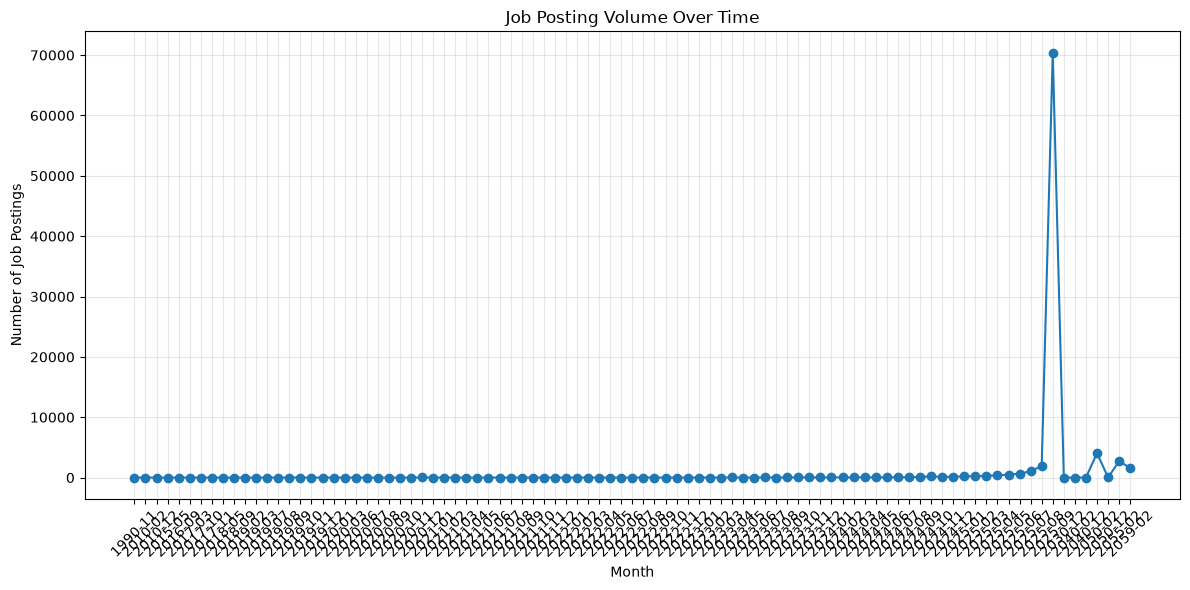

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_jobs["month"],
    monthly_jobs["job_count"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.title("Job Posting Volume Over Time")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [86]:
daily_jobs = (
    job_dates
    .dropna(subset=["job_date"])
    .groupby("job_date")
    .size()
    .reset_index(name="job_count")
)

daily_jobs.sort_values(
    "job_count",
    ascending=False
).head(15)

,job_date,job_count
684,2025-09-29,13439
678,2025-09-23,12579
680,2025-09-25,10872
681,2025-09-26,9986
685,2025-09-30,9579
679,2025-09-24,8827
693,2050-02-11,3231
698,2055-02-11,2723
682,2025-09-27,2393
699,2059-02-11,1585


In [87]:
print("Earliest posting:", job_dates["job_date"].min())
print("Latest posting:", job_dates["job_date"].max())

Earliest posting: 1990-11-21 00:00:00
Latest posting: 2059-02-11 00:00:00


In [88]:
print("Min:", job_dates["job_date"].min())
print("Max:", job_dates["job_date"].max())

print("\nYear distribution:")
print(job_dates["job_date"].dt.year.value_counts().sort_index())

Min: 1990-11-21 00:00:00
Max: 2059-02-11 00:00:00

Year distribution:
job_date
1990.0        1
2010.0        3
2015.0        1
2016.0        1
2017.0        3
2018.0        3
2019.0       31
2020.0       34
2021.0       60
2022.0       62
2023.0      194
2024.0      887
2025.0    75623
2030.0        2
2040.0       16
2050.0     4075
2055.0     2723
2059.0     1585
Name: count, dtype: int64


In [89]:
monthly_jobs.sort_values(
    "job_count",
    ascending=False
).head(15)

,month,job_count
83,2025-09,70419
87,2050-02,4050
89,2055-02,2723
82,2025-08,1908
90,2059-02,1585
81,2025-07,1060
80,2025-06,644
79,2025-05,496
78,2025-04,356
77,2025-03,293


In [90]:
job_dates_2025 = job_dates[
    job_dates["job_date"].dt.year == 2025
].copy()

print("2025 jobs:", len(job_dates_2025))
print(
    "Date range:",
    job_dates_2025["job_date"].min(),
    "to",
    job_dates_2025["job_date"].max()
)

2025 jobs: 75623
Date range: 2025-01-10 00:00:00 to 2025-09-30 00:00:00


In [91]:
monthly_jobs = (
    job_dates_2025
    .groupby(
        job_dates_2025["job_date"].dt.to_period("M")
    )
    .size()
    .reset_index(name="job_count")
)

monthly_jobs["month"] = (
    monthly_jobs["job_date"]
    .astype(str)
)

monthly_jobs

,job_date,job_count,month
0,2025-01,214,2025-01
1,2025-02,233,2025-02
2,2025-03,293,2025-03
3,2025-04,356,2025-04
4,2025-05,496,2025-05
5,2025-06,644,2025-06
6,2025-07,1060,2025-07
7,2025-08,1908,2025-08
8,2025-09,70419,2025-09


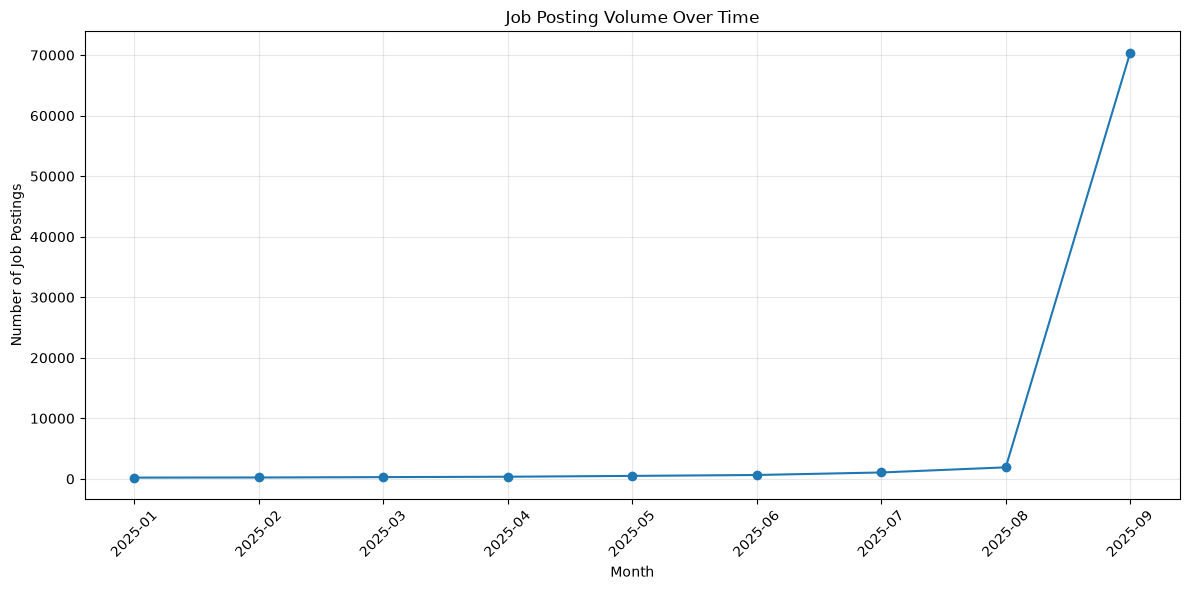

In [92]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_jobs["month"],
    monthly_jobs["job_count"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.title("Job Posting Volume Over Time")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [93]:
daily_jobs = (
    job_dates
    .dropna(subset=["job_date"])
    .groupby("job_date")
    .size()
    .reset_index(name="job_count")
    .sort_values("job_count", ascending=False)
)

daily_jobs.head(15)

,job_date,job_count
684,2025-09-29,13439
678,2025-09-23,12579
680,2025-09-25,10872
681,2025-09-26,9986
685,2025-09-30,9579
679,2025-09-24,8827
693,2050-02-11,3231
698,2055-02-11,2723
682,2025-09-27,2393
699,2059-02-11,1585


In [94]:
role_intelligence = (
    roles
    .dropna(subset=["role"])
    .groupby("role")
    .agg(
        job_count=("job_id", "nunique")
    )
    .reset_index()
)

role_intelligence["demand_percent"] = (
    role_intelligence["job_count"]
    / role_intelligence["job_count"].sum()
    * 100
).round(2)

role_intelligence = role_intelligence.sort_values(
    "job_count",
    ascending=False
)

role_intelligence

,role,job_count,demand_percent
14,Software Engineer,1563,16.30
8,Full Stack Developer,1512,15.77
12,QA / Testing,1145,11.94
4,Data Engineer,1082,11.28
6,DevOps Engineer,664,6.93
9,Java Developer,652,6.80
10,Project Manager,558,5.82
1,Business Analyst,499,5.20
0,Backend Developer,447,4.66
13,Software Developer,319,3.33


In [95]:
role_skill_query = """
SELECT
    r.role,
    s.skill_name,
    COUNT(DISTINCT r.job_id) AS job_count
FROM (
    SELECT
        job_id,
        CASE
            WHEN LOWER(title) LIKE '%data scientist%' THEN 'Data Scientist'
            WHEN LOWER(title) LIKE '%data analyst%' THEN 'Data Analyst'
            WHEN LOWER(title) LIKE '%data engineer%' THEN 'Data Engineer'
            WHEN LOWER(title) LIKE '%python developer%' THEN 'Python Developer'
            WHEN LOWER(title) LIKE '%java developer%' THEN 'Java Developer'
            WHEN LOWER(title) LIKE '%software engineer%' THEN 'Software Engineer'
            WHEN LOWER(title) LIKE '%software developer%' THEN 'Software Developer'
            WHEN LOWER(title) LIKE '%devops%' THEN 'DevOps Engineer'
            WHEN LOWER(title) LIKE '%cloud engineer%' THEN 'Cloud Engineer'
            WHEN LOWER(title) LIKE '%frontend%'
              OR LOWER(title) LIKE '%front end%' THEN 'Frontend Developer'
            WHEN LOWER(title) LIKE '%backend%'
              OR LOWER(title) LIKE '%back end%' THEN 'Backend Developer'
            WHEN LOWER(title) LIKE '%full stack%'
              OR LOWER(title) LIKE '%fullstack%' THEN 'Full Stack Developer'
            WHEN LOWER(title) LIKE '%qa%'
              OR LOWER(title) LIKE '%quality analyst%'
              OR LOWER(title) LIKE '%test engineer%' THEN 'QA / Testing'
            WHEN LOWER(title) LIKE '%business analyst%' THEN 'Business Analyst'
            WHEN LOWER(title) LIKE '%project manager%' THEN 'Project Manager'
            ELSE NULL
        END AS role
    FROM jobs
) r
JOIN job_skills js
    ON r.job_id = js.job_id
JOIN skills s
    ON js.skill_id = s.skill_id
WHERE r.role IS NOT NULL
GROUP BY r.role, s.skill_name
"""

role_skills = pd.read_sql(
    text(role_skill_query),
    engine
)

print(role_skills.shape)
role_skills.head(20)

(2671, 3)


,role,skill_name,job_count
0,Backend Developer,Agile,48
1,Backend Developer,Airflow,6
2,Backend Developer,algorithms,11
3,Backend Developer,Algorithms,8
4,Backend Developer,Amazon Web Services,3
5,Backend Developer,angular,1
6,Backend Developer,Angular,15
7,Backend Developer,Ansible,2
8,Backend Developer,Apache Spark,3
9,Backend Developer,API development,13


In [96]:
role_skills = role_skills.merge(
    role_intelligence[
        ["role", "job_count"]
    ],
    on="role",
    how="left",
    suffixes=("_skill", "_role")
)

role_skills["skill_percent"] = (
    role_skills["job_count_skill"]
    / role_skills["job_count_role"]
    * 100
).round(2)

In [97]:
role_skills = role_skills.rename(
    columns={
        "job_count_skill": "skill_job_count",
        "job_count_role": "role_job_count"
    }
)

In [98]:
role_skills.head(20)

,role,skill_name,skill_job_count,role_job_count,skill_percent
0,Backend Developer,Agile,48,447,10.74
1,Backend Developer,Airflow,6,447,1.34
2,Backend Developer,algorithms,11,447,2.46
3,Backend Developer,Algorithms,8,447,1.79
4,Backend Developer,Amazon Web Services,3,447,0.67
5,Backend Developer,angular,1,447,0.22
6,Backend Developer,Angular,15,447,3.36
7,Backend Developer,Ansible,2,447,0.45
8,Backend Developer,Apache Spark,3,447,0.67
9,Backend Developer,API development,13,447,2.91


In [99]:
top_role_skills = (
    role_skills
    .sort_values(
        ["role", "skill_percent"],
        ascending=[True, False]
    )
    .groupby("role")
    .head(10)
)

top_role_skills

,role,skill_name,skill_job_count,role_job_count,skill_percent
76,Backend Developer,Java,163,447,36.47
144,Backend Developer,Spring,120,447,26.85
96,Backend Developer,Microservices,98,447,21.92
147,Backend Developer,Spring Boot,89,447,19.91
11,Backend Developer,AWS,83,447,18.57
...,...,...,...,...,...
2621,Software Engineer,Software Engineering,223,1563,14.27
2369,Software Engineer,Azure,219,1563,14.01
2582,Software Engineer,Python,213,1563,13.63
2392,Software Engineer,CI/CD,183,1563,11.71


In [100]:
role_skill_summary = (
    top_role_skills
    .groupby("role")
    .apply(
        lambda x: x[
            [
                "skill_name",
                "skill_percent"
            ]
        ].to_dict("records"),
        include_groups=False
    )
    .reset_index(name="top_skills")
)

role_skill_summary

,role,top_skills
0,Backend Developer,"[{'skill_name': 'Java', 'skill_percent': 36.47..."
1,Business Analyst,"[{'skill_name': 'Agile', 'skill_percent': 15.6..."
2,Cloud Engineer,"[{'skill_name': 'AWS', 'skill_percent': 43.62}..."
3,Data Analyst,"[{'skill_name': 'SQL', 'skill_percent': 27.72}..."
4,Data Engineer,"[{'skill_name': 'Python', 'skill_percent': 35...."
5,Data Scientist,"[{'skill_name': 'Python', 'skill_percent': 41...."
6,DevOps Engineer,"[{'skill_name': 'CI/CD', 'skill_percent': 35.2..."
7,Frontend Developer,"[{'skill_name': 'JavaScript', 'skill_percent':..."
8,Full Stack Developer,"[{'skill_name': 'Java', 'skill_percent': 40.67..."
9,Java Developer,"[{'skill_name': 'Java', 'skill_percent': 67.79..."


In [101]:
role_salary = (
    salary_jobs
    .merge(
        roles[["job_id", "role"]],
        on="job_id",
        how="inner"
    )
    .dropna(subset=["role"])
    .groupby("role")
    .agg(
        salary_job_count=("job_id", "nunique"),
        avg_salary=("avg_salary", "mean"),
        median_salary=("avg_salary", "median")
    )
    .reset_index()
)

role_salary["avg_salary_lpa"] = (
    role_salary["avg_salary"] / 100000
).round(2)

role_salary["median_salary_lpa"] = (
    role_salary["median_salary"] / 100000
).round(2)

role_salary

,role,salary_job_count,avg_salary,median_salary,avg_salary_lpa,median_salary_lpa
0,Backend Developer,148,1.282517e+06,1100000.0,12.83,11.00
1,Business Analyst,87,1.200787e+06,1100000.0,12.01,11.00
2,Cloud Engineer,18,1.590278e+06,1550000.0,15.90,15.50
3,Data Analyst,59,1.064407e+06,750000.0,10.64,7.50
4,Data Engineer,319,1.814867e+06,2000000.0,18.15,20.00
5,Data Scientist,48,2.038021e+06,2137500.0,20.38,21.38
6,DevOps Engineer,126,1.610218e+06,1500000.0,16.10,15.00
7,Frontend Developer,65,1.588385e+06,1250000.0,15.88,12.50
8,Full Stack Developer,378,1.596500e+06,1650000.0,15.96,16.50
9,Java Developer,152,1.662845e+06,1675000.0,16.63,16.75


In [102]:
role_master = (
    role_intelligence
    .merge(
        role_salary[
            [
                "role",
                "salary_job_count",
                "avg_salary_lpa",
                "median_salary_lpa"
            ]
        ],
        on="role",
        how="left"
    )
)

In [103]:
role_master = role_master.merge(
    role_skill_summary,
    on="role",
    how="left"
)

In [104]:
role_master = role_master.sort_values(
    "job_count",
    ascending=False
)

role_master

,role,job_count,demand_percent,salary_job_count,avg_salary_lpa,median_salary_lpa,top_skills
0,Software Engineer,1563,16.30,111,16.51,14.00,"[{'skill_name': 'Software Development', 'skill..."
1,Full Stack Developer,1512,15.77,378,15.96,16.50,"[{'skill_name': 'Java', 'skill_percent': 40.67..."
2,QA / Testing,1145,11.94,307,9.41,7.00,"[{'skill_name': 'Selenium', 'skill_percent': 1..."
3,Data Engineer,1082,11.28,319,18.15,20.00,"[{'skill_name': 'Python', 'skill_percent': 35...."
4,DevOps Engineer,664,6.93,126,16.10,15.00,"[{'skill_name': 'CI/CD', 'skill_percent': 35.2..."
5,Java Developer,652,6.80,152,16.63,16.75,"[{'skill_name': 'Java', 'skill_percent': 67.79..."
6,Project Manager,558,5.82,155,13.38,10.50,"[{'skill_name': 'Agile', 'skill_percent': 17.5..."
7,Business Analyst,499,5.20,87,12.01,11.00,"[{'skill_name': 'Agile', 'skill_percent': 15.6..."
8,Backend Developer,447,4.66,148,12.83,11.00,"[{'skill_name': 'Java', 'skill_percent': 36.47..."
9,Software Developer,319,3.33,75,11.22,10.00,"[{'skill_name': 'Python', 'skill_percent': 22...."


In [105]:
role_master.to_csv(
    "role_intelligence.csv",
    index=False
)

print("✅ role_intelligence.csv created")

✅ role_intelligence.csv created


In [109]:
def career_insight(role_name):

    role_match = role_master[
        role_master["role"].str.lower() == role_name.lower()
    ]

    if role_match.empty:
        print("❌ Role not found.")
        print("\nAvailable roles:")
        print(sorted(role_master["role"].dropna().tolist()))
        return

    row = role_match.iloc[0]

    print("=" * 60)
    print(f"💼 CAREER INSIGHT: {row['role']}")
    print("=" * 60)

    # Demand
    print("\n📊 JOB DEMAND")
    print(f"Jobs: {int(row['job_count'])}")
    print(f"Demand share: {row['demand_percent']:.2f}%")

    # Salary
    print("\n💰 SALARY")

    if pd.notna(row["avg_salary_lpa"]):
        print(f"Average: ₹{row['avg_salary_lpa']:.2f} LPA")

    if pd.notna(row["median_salary_lpa"]):
        print(f"Median: ₹{row['median_salary_lpa']:.2f} LPA")

    print(f"Salary sample: {int(row['salary_job_count'])} jobs")

    # Skills
    print("\n🔥 TOP SKILLS")

    skills = row["top_skills"]

    if isinstance(skills, list):
        for i, skill in enumerate(skills, 1):
            print(
                f"{i}. {skill['skill_name']} "
                f"({skill['skill_percent']:.2f}%)"
            )
    else:
        print("No skill data available.")

    # Cities
    print("\n📍 TOP CITIES")

    cities = top_role_cities[
        top_role_cities["role"] == row["role"]
    ].head(5)

    if cities.empty:
        print("No city data available.")
    else:
        for _, city in cities.iterrows():
            print(
                f"{city['city']}: "
                f"{int(city['job_count'])} jobs"
            )

    print("\n" + "=" * 60)

In [111]:
role_city_query = """
SELECT
    j.job_id,
    j.location,
    r.role
FROM jobs j
JOIN (
    SELECT
        job_id,
        CASE
            WHEN LOWER(title) LIKE '%data scientist%' THEN 'Data Scientist'
            WHEN LOWER(title) LIKE '%data analyst%' THEN 'Data Analyst'
            WHEN LOWER(title) LIKE '%data engineer%' THEN 'Data Engineer'
            WHEN LOWER(title) LIKE '%python developer%' THEN 'Python Developer'
            WHEN LOWER(title) LIKE '%java developer%' THEN 'Java Developer'
            WHEN LOWER(title) LIKE '%software engineer%' THEN 'Software Engineer'
            WHEN LOWER(title) LIKE '%software developer%' THEN 'Software Developer'
            WHEN LOWER(title) LIKE '%devops%' THEN 'DevOps Engineer'
            WHEN LOWER(title) LIKE '%cloud engineer%' THEN 'Cloud Engineer'
            WHEN LOWER(title) LIKE '%frontend%'
              OR LOWER(title) LIKE '%front end%' THEN 'Frontend Developer'
            WHEN LOWER(title) LIKE '%backend%'
              OR LOWER(title) LIKE '%back end%' THEN 'Backend Developer'
            WHEN LOWER(title) LIKE '%full stack%'
              OR LOWER(title) LIKE '%fullstack%' THEN 'Full Stack Developer'
            WHEN LOWER(title) LIKE '%qa%'
              OR LOWER(title) LIKE '%quality analyst%'
              OR LOWER(title) LIKE '%test engineer%' THEN 'QA / Testing'
            WHEN LOWER(title) LIKE '%business analyst%' THEN 'Business Analyst'
            WHEN LOWER(title) LIKE '%project manager%' THEN 'Project Manager'
            ELSE NULL
        END AS role
    FROM jobs
) r
ON j.job_id = r.job_id
WHERE r.role IS NOT NULL
  AND j.location IS NOT NULL;
"""

role_city = pd.read_sql(
    text(role_city_query),
    engine
)

role_city["city"] = (
    role_city["location"]
    .str.split(",")
    .str[0]
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.replace(
        r"^Hybrid\s*-\s*",
        "",
        regex=True,
        case=False
    )
    .str.strip()
)

role_city_counts = (
    role_city
    .groupby(["role", "city"])["job_id"]
    .nunique()
    .reset_index(name="job_count")
)

top_role_cities = (
    role_city_counts
    .sort_values(
        ["role", "job_count"],
        ascending=[True, False]
    )
    .groupby("role")
    .head(5)
)

print(top_role_cities[
    top_role_cities["role"] == "Data Engineer"
])

              role       city  job_count
128  Data Engineer  Bengaluru        216
142  Data Engineer  Hyderabad        202
180  Data Engineer       Pune        140
133  Data Engineer    Chennai         64
140  Data Engineer   Gurugram         51


In [112]:
career_insight("Data Engineer")

💼 CAREER INSIGHT: Data Engineer

📊 JOB DEMAND
Jobs: 1082
Demand share: 11.28%

💰 SALARY
Average: ₹18.15 LPA
Median: ₹20.00 LPA
Salary sample: 319 jobs

🔥 TOP SKILLS
1. Python (35.77%)
2. Data Engineering (35.21%)
3. SQL (34.01%)
4. ETL (27.91%)
5. AWS (25.32%)
6. Agile (23.20%)
7. Scala (23.11%)
8. Azure (19.69%)
9. Jenkins (19.13%)
10. GCP (18.21%)

📍 TOP CITIES
Bengaluru: 216 jobs
Hyderabad: 202 jobs
Pune: 140 jobs
Chennai: 64 jobs
Gurugram: 51 jobs



In [113]:
role_master["salary_score"] = (
    role_master["median_salary_lpa"]
    / role_master["median_salary_lpa"].max()
) * 100

role_master["demand_score"] = (
    role_master["job_count"]
    / role_master["job_count"].max()
) * 100

role_master["opportunity_score"] = (
    0.6 * role_master["demand_score"] +
    0.4 * role_master["salary_score"]
)

role_ranking = (
    role_master[
        [
            "role",
            "job_count",
            "demand_percent",
            "median_salary_lpa",
            "demand_score",
            "salary_score",
            "opportunity_score"
        ]
    ]
    .sort_values(
        "opportunity_score",
        ascending=False
    )
    .reset_index(drop=True)
)

role_ranking


,role,job_count,demand_percent,median_salary_lpa,demand_score,salary_score,opportunity_score
0,Full Stack Developer,1512,15.77,16.50,96.737044,77.174930,88.912198
1,Software Engineer,1563,16.30,14.00,100.000000,65.481759,86.192703
2,Data Engineer,1082,11.28,20.00,69.225848,93.545370,78.953656
3,QA / Testing,1145,11.94,7.00,73.256558,32.740879,57.050286
4,Java Developer,652,6.80,16.75,41.714651,78.344247,56.366490
5,DevOps Engineer,664,6.93,15.00,42.482406,70.159027,53.553054
6,Data Scientist,317,3.31,21.38,20.281510,100.000000,52.168906
7,Project Manager,558,5.82,10.50,35.700576,49.111319,41.064873
8,Business Analyst,499,5.20,11.00,31.925784,51.449953,39.735452
9,Backend Developer,447,4.66,11.00,28.598848,51.449953,37.739290


In [114]:
role_ranking.head(10)

,role,job_count,demand_percent,median_salary_lpa,demand_score,salary_score,opportunity_score
0,Full Stack Developer,1512,15.77,16.50,96.737044,77.174930,88.912198
1,Software Engineer,1563,16.30,14.00,100.000000,65.481759,86.192703
2,Data Engineer,1082,11.28,20.00,69.225848,93.545370,78.953656
3,QA / Testing,1145,11.94,7.00,73.256558,32.740879,57.050286
4,Java Developer,652,6.80,16.75,41.714651,78.344247,56.366490
5,DevOps Engineer,664,6.93,15.00,42.482406,70.159027,53.553054
6,Data Scientist,317,3.31,21.38,20.281510,100.000000,52.168906
7,Project Manager,558,5.82,10.50,35.700576,49.111319,41.064873
8,Business Analyst,499,5.20,11.00,31.925784,51.449953,39.735452
9,Backend Developer,447,4.66,11.00,28.598848,51.449953,37.739290


In [115]:
print(role_master.shape)
print(role_master.columns.tolist())

(15, 10)
['role', 'job_count', 'demand_percent', 'salary_job_count', 'avg_salary_lpa', 'median_salary_lpa', 'top_skills', 'salary_score', 'demand_score', 'opportunity_score']


In [116]:
role_master.to_csv(
    "../data/role_intelligence.csv",
    index=False
)

print("✅ role_intelligence.csv recreated")
print(role_master.shape)

✅ role_intelligence.csv recreated
(15, 10)


In [118]:
import pandas as pd

print("DataFrames currently available:\n")

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"{name:25} {obj.shape}")

DataFrames currently available:

__                        (20, 6)
___                       (30, 6)
skill_demand              (618, 3)
_2                        (30, 2)
_3                        (30, 3)
top20                     (20, 3)
_8                        (20, 3)
roles                     (97679, 3)
role_counts               (15, 2)
_12                       (15, 2)
role_skills               (2671, 5)
_13                       (30, 3)
top_role_skills           (150, 5)
_14                       (150, 3)
_15                       (60, 3)
role_totals               (15, 2)
role_skill_analysis       (2671, 5)
_16                       (20, 5)
top_role_skills_pct       (150, 5)
_17                       (150, 5)
_18                       (60, 5)
heatmap_data              (60, 5)
pivot                     (6, 38)
_19                       (6, 38)
salary_jobs               (33136, 5)
salary_roles              (33136, 6)
salary_by_role            (15, 3)
_23                       (15, 

In [119]:
print("city_salary:")
print(city_salary.head())
print(city_salary.columns.tolist())
print()

print("major_city_salary:")
print(major_city_salary.head())
print(major_city_salary.columns.tolist())

city_salary:
            job_count    avg_salary  median_salary  avg_salary_lpa  \
city_clean                                                           
Dahej              36  1.462847e+06       962500.0           14.63   
Bareilly           39  2.149295e+06       750000.0           21.49   
Karimnagar         33  9.409091e+05       725000.0            9.41   
Remote            775  1.001040e+06       600000.0           10.01   
Bhopal             44  8.664773e+05       575000.0            8.66   

            median_salary_lpa  
city_clean                     
Dahej                    9.62  
Bareilly                 7.50  
Karimnagar               7.25  
Remote                   6.00  
Bhopal                   5.75  
['job_count', 'avg_salary', 'median_salary', 'avg_salary_lpa', 'median_salary_lpa']

major_city_salary:
            job_count    avg_salary  median_salary  avg_salary_lpa  \
city_clean                                                           
Remote            775  1.001

In [120]:
# ============================================================
# EXPORT FINAL DATASETS FOR STREAMLIT DASHBOARD
# ============================================================

# 1. Role intelligence
role_master.to_csv(
    "../data/role_intelligence.csv",
    index=False
)

# 2. Role ranking
role_ranking.to_csv(
    "../data/role_ranking.csv",
    index=False
)

# 3. Skill demand
skill_demand.to_csv(
    "../data/skill_demand.csv",
    index=False
)

# 4. City intelligence
city_intelligence_export = (
    city_salary
    .reset_index()
)

city_intelligence_export.to_csv(
    "../data/city_intelligence.csv",
    index=False
)

# 5. Skill pairs
skill_combinations.to_csv(
    "../data/skill_pairs.csv",
    index=False
)

print("✅ ALL DASHBOARD DATASETS EXPORTED")
print()

print("role_intelligence :", role_master.shape)
print("role_ranking      :", role_ranking.shape)
print("skill_demand      :", skill_demand.shape)
print("city_intelligence :", city_intelligence_export.shape)
print("skill_pairs       :", skill_combinations.shape)

✅ ALL DASHBOARD DATASETS EXPORTED

role_intelligence : (15, 10)
role_ranking      : (15, 7)
skill_demand      : (618, 3)
city_intelligence : (85, 6)
skill_pairs       : (10, 7)


In [121]:
role_city_counts.to_csv(
    "../data/role_city_counts.csv",
    index=False
)

print("✅ role_city_counts.csv created")
print(role_city_counts.shape)
print(role_city_counts.columns.tolist())

✅ role_city_counts.csv created
(730, 3)
['role', 'city', 'job_count']


In [122]:
role_city_counts.to_csv(
    "../data/role_city_counts.csv",
    index=False
)

print("✅ role_city_counts.csv created")
print(role_city_counts.shape)
print(role_city_counts.columns.tolist())

✅ role_city_counts.csv created
(730, 3)
['role', 'city', 'job_count']
